# 🏥 FallDeWideo — Exploration & Visualisation du Dataset CSI
## Notebook d'Analyse Exploratoire (EDA) — Modalité CSI
### Cai et al., ISACom 2023 | Kaggle Notebook

---

**Objectif** : Explorer et comprendre le dataset multimodal FallDeWideo
avant tout prétraitement ou entraînement de modèle.

**Dataset** : WiFi CSI + OpenPose + MaskRCNN pour la détection de chutes
- 10 fichiers pickle × ~4020 lignes = **40 200 échantillons**
- 3 modalités : CSI (signal WiFi), OpenPose (pose humaine), MaskRCNN (masque)
- 15 classes d'activités : 5 falls + 5 non-fall-1 + 5 non-fall-2

**Plan du notebook** :
1. Setup & vérification des chemins
2. Exploration de la structure des fichiers
3. Vue d'ensemble des 10 fichiers
4. Reconstruction des métadonnées
5. Profiling automatique (ydata-profiling)
6. Visualisation de l'équilibre des classes
7. Distribution temporelle
8. Qualité du signal CSI
9. Comparaison des 3 receivers
10. Synthèse & plan de prétraitement

In [1]:
# ============================================================
# CELLULE 0 — Setup : chemins unifiés des 3 modalités
# Aucune copie de fichier — tout reste dans /kaggle/input/
# full_0–7 CSI    : csi/csi/
# full_8–9 CSI    : missing/missing/csi/
# full_0 OpenPose : missing/missing/openpose/
# full_1–9 OpenPose: openpose/openpose/
# full_0–9 MaskRCNN: maskrcnn (2)/maskrcnn/
# ============================================================
import os

BASE = "/kaggle/input/datasets/imanemokhtari/falldewideoo"

CSI_FILES = [f"{BASE}/csi/csi/full_{i}.pk" for i in range(8)] + \
            [f"{BASE}/missing/missing/csi/full_8.pk",
             f"{BASE}/missing/missing/csi/full_9.pk"]

OPENPOSE_FILES = [f"{BASE}/missing/missing/openpose/full_0.pk"] + \
                 [f"{BASE}/openpose/openpose/full_{i}.pk"
                  for i in range(1, 10)]

MASKRCNN_FILES = [f"{BASE}/maskrcnn (2)/maskrcnn/full_{i}.pk"
                  for i in range(10)]

print("=" * 60)
for name, files in [("CSI", CSI_FILES),
                    ("OpenPose", OPENPOSE_FILES),
                    ("MaskRCNN", MASKRCNN_FILES)]:
    ok = sum(os.path.exists(p) for p in files)
    print(f"{'✅' if ok == 10 else '⚠️'} {name:10s} : {ok}/10 fichiers trouvés")
    for p in files:
        exists = os.path.exists(p)
        src    = "missing" if "missing" in p else "normal"
        print(f"  {'✅' if exists else '❌'} {p.split('/')[-1]:12s} "
              f"[{src:7s}] → {p}")
print("=" * 60)

✅ CSI        : 10/10 fichiers trouvés
  ✅ full_0.pk    [normal ] → /kaggle/input/datasets/imanemokhtari/falldewideoo/csi/csi/full_0.pk
  ✅ full_1.pk    [normal ] → /kaggle/input/datasets/imanemokhtari/falldewideoo/csi/csi/full_1.pk
  ✅ full_2.pk    [normal ] → /kaggle/input/datasets/imanemokhtari/falldewideoo/csi/csi/full_2.pk
  ✅ full_3.pk    [normal ] → /kaggle/input/datasets/imanemokhtari/falldewideoo/csi/csi/full_3.pk
  ✅ full_4.pk    [normal ] → /kaggle/input/datasets/imanemokhtari/falldewideoo/csi/csi/full_4.pk
  ✅ full_5.pk    [normal ] → /kaggle/input/datasets/imanemokhtari/falldewideoo/csi/csi/full_5.pk
  ✅ full_6.pk    [normal ] → /kaggle/input/datasets/imanemokhtari/falldewideoo/csi/csi/full_6.pk
  ✅ full_7.pk    [normal ] → /kaggle/input/datasets/imanemokhtari/falldewideoo/csi/csi/full_7.pk
  ✅ full_8.pk    [missing] → /kaggle/input/datasets/imanemokhtari/falldewideoo/missing/missing/csi/full_8.pk
  ✅ full_9.pk    [missing] → /kaggle/input/datasets/imanemokhtari/falldewideo

## 📡 Structure des Données CSI — FallDeWideo

### Structure d'un fichier `.pk`
Chaque fichier est un **DataFrame Pandas** de ~4020 lignes × 4 colonnes :

| Colonne | Type | Contenu |
|---------|------|---------|
| `pic`   | str  | Chemin vers le frame vidéo synchronisé |
| `csi0`  | ndarray complex128 | Signal CSI du **receiver 0** |
| `csi1`  | ndarray complex128 | Signal CSI du **receiver 1** |
| `csi2`  | ndarray complex128 | Signal CSI du **receiver 2** |

### 🔢 Shape d'un sample CSI : `(50, 30, 3, 3)`

```
csi0[i].shape = (50, 30, 3, 3)
                  │   │  │  │
                  │   │  │  └── RX : 3 antennes réceptrices
                  │   │  └───── TX : 3 antennes émettrices
                  │   └──────── 30 subcarriers (sous-porteuses OFDM)
                  └──────────── 50 paquets (= 50 ms à 1000 Hz)
```

### 📶 C'est quoi un subcarrier ?
Le WiFi utilise **OFDM** : au lieu d'une seule fréquence, le canal est
divisé en **30 sous-fréquences parallèles**. Quand un corps humain bouge,
il perturbe chaque subcarrier **différemment** selon l'angle et la distance.
→ 30 × 3TX × 3RX = **270 mesures simultanées** par paquet.

### 📊 À quoi sert chaque amplitude ?
| Quantité | Formule | Signification |
|----------|---------|--------------|
| **Amplitude** `\|H\|` | `√(a²+b²)` | Force du signal — change avec le mouvement |
| **Phase** `∠H` | `arctan(b/a)` | Décalage temporel — sensible aux micro-mouvements |

### ⏱️ Timing
- **1 ligne** = 50 paquets = **50 ms**
- **1 fichier** = 4020 lignes = **201 secondes** de signal
- **10 fichiers** = **40 200 lignes** = **33.5 minutes** de signal total

### 🔗 Lien avec le papier (Cai et al., ISACom 2023)
> *"We extract the amplitude and denoised phase of CSI from 3 receivers.
> The input is reshaped as tensors of size **54 × 30 × 50**"*

In [2]:
# ============================================================
# CELLULE 1 — Exploration structure (1 seul fichier)
# But : comprendre exactement ce qu'il y a dans les pickles
# IMPORTANT : del + gc.collect() après pour libérer la RAM
# ============================================================
import pickle
import numpy as np
import gc

with open(CSI_FILES[0], "rb") as f:
    df0 = pickle.load(f)

print("=" * 60)
print(f"Type     : {type(df0)}")
print(f"Shape    : {df0.shape}")
print(f"Colonnes : {df0.columns.tolist()}")
print(f"Dtypes   :\n{df0.dtypes}")

print(f"\n{'─'*60}")
print("CONTENU DÉTAILLÉ — première ligne :")
for col in df0.columns:
    val = df0[col].iloc[0]
    print(f"\n  Colonne '{col}':")
    print(f"    type  = {type(val).__name__}")
    if hasattr(val, 'shape'):
        print(f"    shape = {val.shape}")
        print(f"    dtype = {val.dtype}")
        print(f"    min   = {val.min():.4f}  max = {val.max():.4f}")
    elif isinstance(val, str):
        print(f"    valeur= '{val}'")
        parts = val.split('/')
        print(f"    parts = {parts}")

print(f"\n{'─'*60}")
print(f"1 fichier = {len(df0)} lignes = {len(df0)*50/1000:.0f} sec de signal")
print(f"1 ligne   = shape {df0['csi0'].iloc[0].shape}")
print(f"            50 paquets × 30 subcarriers × 3TX × 3RX")
print(f"Dtype     : complex128 → amplitude + phase")

del df0; gc.collect()
print("\n✅ Mémoire libérée")

Type     : <class 'pandas.core.frame.DataFrame'>
Shape    : (4020, 4)
Colonnes : ['pic', 'csi0', 'csi1', 'csi2']
Dtypes   :
pic     object
csi0    object
csi1    object
csi2    object
dtype: object

────────────────────────────────────────────────────────────
CONTENU DÉTAILLÉ — première ligne :

  Colonne 'pic':
    type  = str
    valeur= '/home/sensing/caizhijie/0702-falldewideo/data/20230612_35/falldewideo1_nfall2_lxh_lights_1000_a3_5_rc/t2_2023_06_12_21_26_54_969/2023_06_12_21_26_55_172.jpg'
    parts = ['', 'home', 'sensing', 'caizhijie', '0702-falldewideo', 'data', '20230612_35', 'falldewideo1_nfall2_lxh_lights_1000_a3_5_rc', 't2_2023_06_12_21_26_54_969', '2023_06_12_21_26_55_172.jpg']

  Colonne 'csi0':
    type  = ndarray
    shape = (50, 30, 3, 3)
    dtype = complex128
    min   = -71.6289+31.8972j  max = 71.0693+0.0000j

  Colonne 'csi1':
    type  = ndarray
    shape = (50, 30, 3, 3)
    dtype = complex128
    min   = -71.0693+10.0728j  max = 71.0693+18.4668j

  Colonne 'cs

Fichier      |  Taille | Lignes |   Durée |  Amp.moy | Source
─────────────────────────────────────────────────────────────────
📄 full_0.pk    |   2606MB |  4020 lg |  201.0s |   30.779 | csi/csi
📄 full_1.pk    |   2606MB |  4020 lg |  201.0s |   31.207 | csi/csi
📄 full_2.pk    |   2606MB |  4020 lg |  201.0s |   31.149 | csi/csi
📄 full_3.pk    |   2606MB |  4020 lg |  201.0s |   29.333 | csi/csi
📄 full_4.pk    |   2606MB |  4020 lg |  201.0s |   32.951 | csi/csi
📄 full_5.pk    |   2606MB |  4020 lg |  201.0s |   38.024 | csi/csi
📄 full_6.pk    |   2606MB |  4020 lg |  201.0s |   36.458 | csi/csi
📄 full_7.pk    |   2606MB |  4020 lg |  201.0s |   34.032 | csi/csi
📦 full_8.pk    |   2606MB |  4020 lg |  201.0s |   35.096 | missing
📦 full_9.pk    |   2606MB |  4020 lg |  201.0s |   35.293 | missing


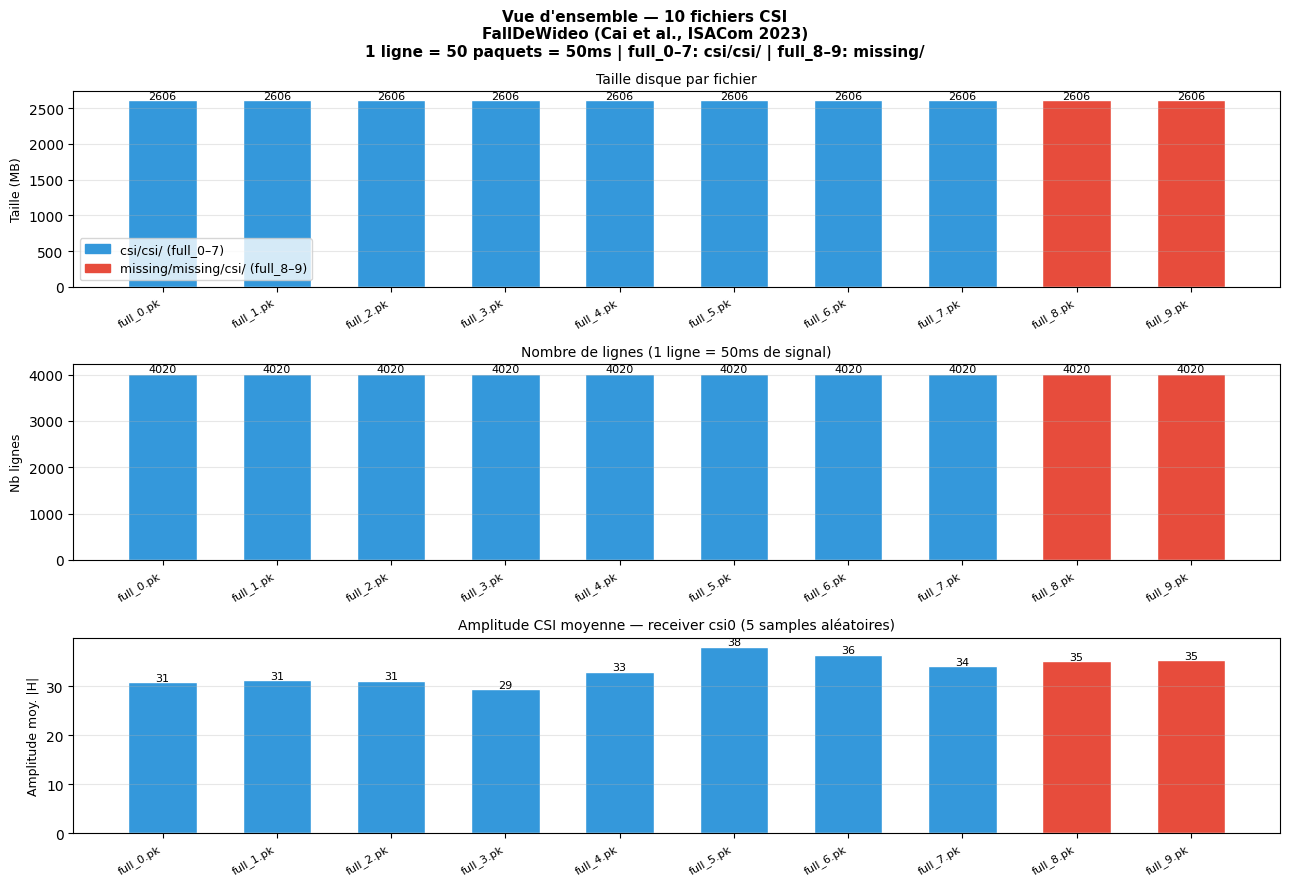


📊 Total : 26062 MB | 40,200 lignes | 33.5 min de signal


In [3]:
# ============================================================
# CELLULE 2 — Vue d'ensemble des 10 fichiers CSI
# On charge UN fichier à la fois → del + gc après chaque
# ============================================================
import pickle, os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import gc

rows = []
print(f"{'Fichier':12s} | {'Taille':>7s} | {'Lignes':>6s} | "
      f"{'Durée':>7s} | {'Amp.moy':>8s} | Source")
print("─" * 65)

for path in CSI_FILES:
    fname   = path.split('/')[-1]
    size_mb = os.path.getsize(path) / 1e6
    src     = "missing" if "missing" in path else "csi/csi"

    with open(path, "rb") as f:
        df = pickle.load(f)

    n_lines  = len(df)
    duree_s  = n_lines * 50 / 1000
    idx_s    = np.random.choice(n_lines, 5, replace=False)
    amp_mean = np.mean([np.abs(df['csi0'].iloc[i]).mean()
                        for i in idx_s])
    rows.append((fname, size_mb, n_lines, duree_s, amp_mean, src))

    icon = "📦" if src == "missing" else "📄"
    print(f"{icon} {fname:12s} | {size_mb:6.0f}MB | {n_lines:5d} lg | "
          f"{duree_s:6.1f}s | {amp_mean:8.3f} | {src}")

    del df; gc.collect()

# ── Graphiques ───────────────────────────────────────────────
fnames = [r[0] for r in rows]
sizes  = [r[1] for r in rows]
nlines = [r[2] for r in rows]
amps   = [r[4] for r in rows]
colors = ['#e74c3c' if r[5]=='missing' else '#3498db' for r in rows]
x      = np.arange(len(fnames))

fig, axes = plt.subplots(3, 1, figsize=(13, 9))
fig.suptitle("Vue d'ensemble — 10 fichiers CSI\n"
             "FallDeWideo (Cai et al., ISACom 2023)\n"
             "1 ligne = 50 paquets = 50ms | "
             "full_0–7: csi/csi/ | full_8–9: missing/",
             fontsize=11, fontweight='bold')

for ax, vals, ylabel, title in zip(
    axes,
    [sizes, nlines, amps],
    ["Taille (MB)", "Nb lignes", "Amplitude moy. |H|"],
    ["Taille disque par fichier",
     "Nombre de lignes (1 ligne = 50ms de signal)",
     "Amplitude CSI moyenne — receiver csi0 (5 samples aléatoires)"]
):
    bars = ax.bar(x, vals, color=colors, edgecolor='white', width=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(fnames, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()*1.01,
                f"{v:.0f}", ha='center', fontsize=8)

axes[0].legend(handles=[
    Patch(color='#3498db', label='csi/csi/ (full_0–7)'),
    Patch(color='#e74c3c', label='missing/missing/csi/ (full_8–9)')],
    fontsize=9)

plt.tight_layout()
plt.savefig("/kaggle/working/csi_overview.png",
            dpi=120, bbox_inches='tight')
plt.show()
print(f"\n📊 Total : {sum(sizes):.0f} MB | "
      f"{sum(nlines):,} lignes | "
      f"{sum([r[3] for r in rows])/60:.1f} min de signal")

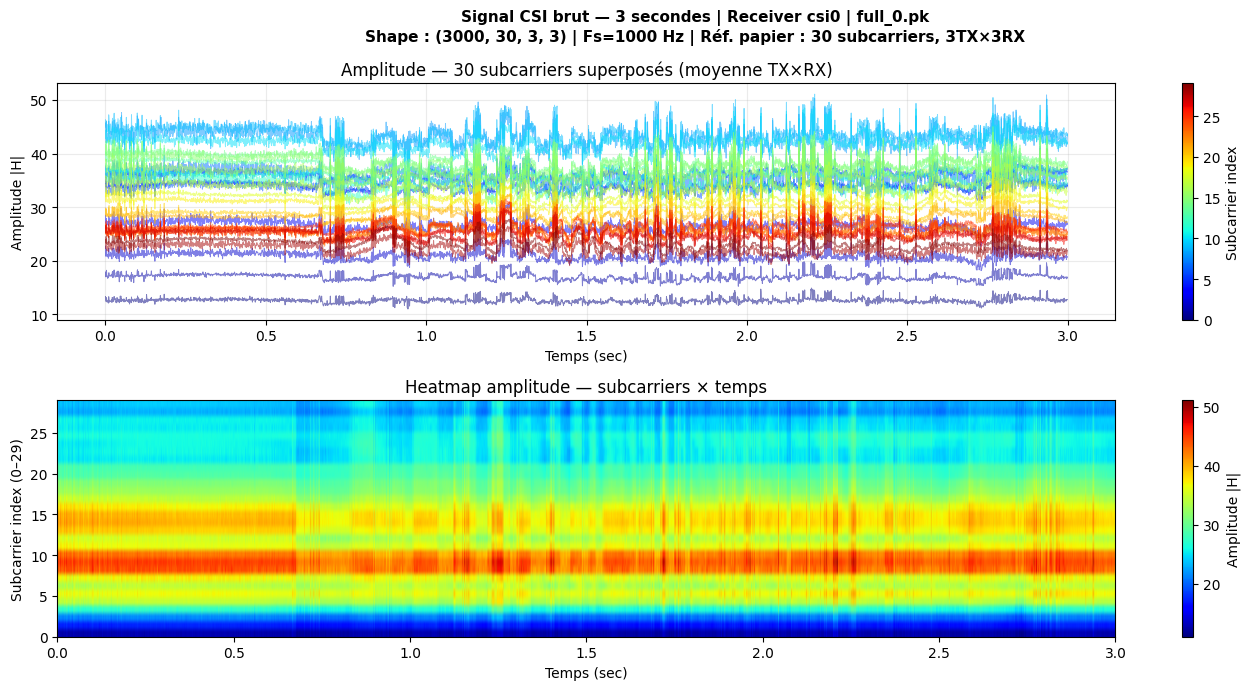

Shape stacked : (60, 50, 30, 3, 3)
Shape flat    : (3000, 30, 3, 3)
Amp min=0.0000  max=98.9528  mean=30.6576


In [4]:
# ============================================================
# CELLULE 3 — Visualisation signal CSI brut (3 secondes)
# Montre l'amplitude des 30 subcarriers dans le temps
# + heatmap subcarriers × temps
# ============================================================
import pickle
import numpy as np
import matplotlib.pyplot as plt
import gc

START_LINE = 0
DURATION_S = 3
RECEIVER   = 'csi0'
n_lines    = int(DURATION_S * 1000 / 50)   # 60 lignes = 3 sec

with open(CSI_FILES[0], "rb") as f:
    df = pickle.load(f)

segment   = df[RECEIVER].iloc[START_LINE:START_LINE + n_lines]
csi_stack = np.stack(segment.values)         # (60, 50, 30, 3, 3)
csi_flat  = csi_stack.reshape(-1, 30, 3, 3) # (3000, 30, 3, 3)
amp       = np.abs(csi_flat)
amp_mean  = amp.mean(axis=(2, 3))           # (3000, 30)
t         = np.arange(len(amp_mean)) / 1000

del df; gc.collect()

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
fig.suptitle(f"Signal CSI brut — {DURATION_S} secondes | "
             f"Receiver {RECEIVER} | full_0.pk\n"
             f"Shape : {csi_flat.shape} | Fs=1000 Hz | "
             f"Réf. papier : 30 subcarriers, 3TX×3RX",
             fontsize=11, fontweight='bold')

cmap30 = plt.cm.jet(np.linspace(0, 1, 30))
ax = axes[0]
for sc in range(30):
    ax.plot(t, amp_mean[:, sc], alpha=0.5,
            linewidth=0.7, color=cmap30[sc])
ax.set_ylabel("Amplitude |H|")
ax.set_xlabel("Temps (sec)")
ax.set_title("Amplitude — 30 subcarriers superposés (moyenne TX×RX)")
ax.grid(True, alpha=0.25)
sm = plt.cm.ScalarMappable(cmap='jet',
     norm=plt.Normalize(vmin=0, vmax=29))
plt.colorbar(sm, ax=ax, label="Subcarrier index")

ax = axes[1]
im = ax.imshow(amp_mean.T, aspect='auto', cmap='jet',
               origin='lower',
               extent=[0, DURATION_S, 0, 29])
ax.set_xlabel("Temps (sec)")
ax.set_ylabel("Subcarrier index (0–29)")
ax.set_title("Heatmap amplitude — subcarriers × temps")
plt.colorbar(im, ax=ax, label="Amplitude |H|")

plt.tight_layout()
plt.savefig("/kaggle/working/csi_signal_brut.png",
            dpi=120, bbox_inches='tight')
plt.show()

print(f"Shape stacked : {csi_stack.shape}")
print(f"Shape flat    : {csi_flat.shape}")
print(f"Amp min={amp.min():.4f}  max={amp.max():.4f}  mean={amp.mean():.4f}")

In [5]:
# ============================================================
# CELLULE 4 — Reconstruction du DataFrame de métadonnées
# On extrait UNIQUEMENT les métadonnées (pas les arrays CSI)
# → metadf léger, pas de crash mémoire
# Structure path[7] :
# falldewideo1_fall_lxh_lights_1000_a3_5_rc
#      [0]     [1]  [2]   [3]   [4] [5][6][7]
# ============================================================
import pickle
import pandas as pd
import numpy as np
import datetime
import gc

def parse_ts(pic_path):
    try:
        return datetime.datetime.strptime(
            pic_path.split('/')[-1].split('.')[0],
            '%Y_%m_%d_%H_%M_%S_%f').timestamp()
    except:
        return np.nan

def extract_meta(pic_path):
    try:
        p = pic_path
        # Corrections officielles (repo GitHub falldewideo)
        if '35_falldewideo_fall_test_lights_1000_' in p \
                and '20230612' in p:
            p = p.replace('35_falldewideo_fall_test_lights_1000_',
                          '35_falldewideo1_fall_mfy_lights_1000_')
        if '20230612' in p:
            p = p.replace('falldewideo_', 'falldewideo1_')
        p = p.replace('falldewideo_1', 'falldewideo1')

        parts = p.split('/')
        sess  = parts[7].split('_')
        return {'db'   : sess[0], 'move' : sess[1],
                'obj'  : sess[2], 'light': sess[3],
                'freq' : sess[4], 'angle': sess[5],
                'site' : sess[6], 'dir'  : parts[6]}
    except:
        return {k: '?' for k in
                ['db','move','obj','light','freq','angle','site','dir']}

print("Extraction métadonnées — 10 fichiers CSI...")
meta_rows = []

for file_idx, path in enumerate(CSI_FILES):
    fname = path.split('/')[-1]
    src   = "missing" if "missing" in path else "csi/csi"

    with open(path, "rb") as f:
        df_raw = pickle.load(f)

    pics = df_raw['pic'].tolist()
    del df_raw; gc.collect()

    for row_idx, pic in enumerate(pics):
        meta = extract_meta(pic)
        meta_rows.append({
            'pic'      : pic,
            'timestamp': parse_ts(pic),
            'file_idx' : file_idx,
            'file_name': fname,
            'file_src' : src,
            'row_idx'  : row_idx,
            **meta
        })

    print(f"  ✅ {fname} — {len(pics)} lignes")

metadf = pd.DataFrame(meta_rows)
metadf.sort_values('timestamp', ignore_index=True, inplace=True)

print(f"\n✅ metadf : {metadf.shape[0]} lignes × {metadf.shape[1]} col")
print(f"Colonnes : {metadf.columns.tolist()}")
print(f"\n📊 move :")
print(metadf['move'].value_counts().to_string())
print(f"\n📊 obj   : {sorted(metadf['obj'].unique().tolist())}")
print(f"📊 angle : {sorted(metadf['angle'].unique().tolist())}")
print(f"📊 site  : {sorted(metadf['site'].unique().tolist())}")

Extraction métadonnées — 10 fichiers CSI...
  ✅ full_0.pk — 4020 lignes
  ✅ full_1.pk — 4020 lignes
  ✅ full_2.pk — 4020 lignes
  ✅ full_3.pk — 4020 lignes
  ✅ full_4.pk — 4020 lignes
  ✅ full_5.pk — 4020 lignes
  ✅ full_6.pk — 4020 lignes
  ✅ full_7.pk — 4020 lignes
  ✅ full_8.pk — 4020 lignes
  ✅ full_9.pk — 4020 lignes

✅ metadf : 40200 lignes × 14 col
Colonnes : ['pic', 'timestamp', 'file_idx', 'file_name', 'file_src', 'row_idx', 'db', 'move', 'obj', 'light', 'freq', 'angle', 'site', 'dir']

📊 move :
move
nfall1    15000
nfall2    14300
fall      10900

📊 obj   : ['chl', 'chz', 'ctw', 'czj', 'lxh', 'mfy']
📊 angle : ['a1', 'a2', 'a3', 'a4']
📊 site  : ['5']


In [6]:
# ============================================================
# CELLULE 5 — Profiling automatique ydata-profiling
# Sur metadf uniquement (léger — pas d'arrays CSI)
# ============================================================
!pip install ydata-profiling --quiet

from ydata_profiling import ProfileReport

profile = ProfileReport(
    metadf[['move','obj','angle','site','dir',
            'light','freq','file_name','file_src']],
    title="FallDeWideo — Profiling métadonnées CSI",
    explorative=True,
    minimal=True   # True = plus léger sur Kaggle
)
profile.to_file("/kaggle/working/csi_profiling.html")
print("✅ Rapport HTML : /kaggle/working/csi_profiling.html")
profile.to_notebook_iframe()

/tmp/ipykernel_58/3748278185.py:7: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport
/usr/local/lib/python3.12/dist-packages/ydata_profiling/utils/dataframe.py:137: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={"index": "df_index"}, inplace=True)


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 9/9 [00:00<00:00, 147.43it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Rapport HTML : /kaggle/working/csi_profiling.html


/tmp/ipykernel_58/2394950105.py:96: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ratio = metadf.groupby('obj').apply(


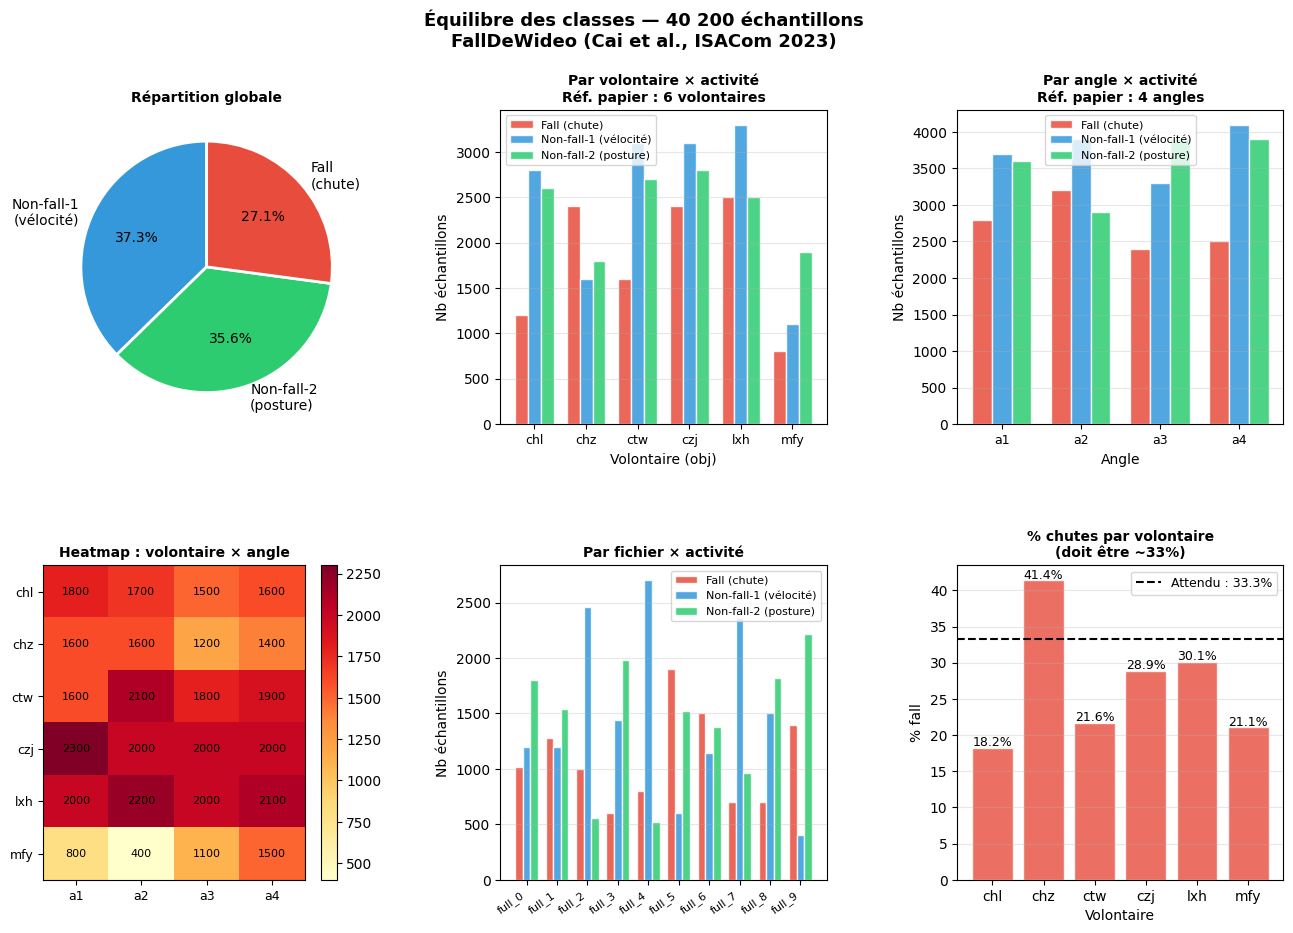

✅ fall=10900 | nfall1=15000 | nfall2=14300


In [7]:
# ============================================================
# CELLULE 6 — Équilibre des classes
# Réf. papier : 240 fall / 480 non-fall
# 15 activités × 4 angles × 6 volontaires × 2 environnements
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

MOVE_NAMES = {'fall':'Fall\n(chute)',
              'nfall1':'Non-fall-1\n(vélocité)',
              'nfall2':'Non-fall-2\n(posture)'}
COLORS = {'fall':'#e74c3c','nfall1':'#3498db','nfall2':'#2ecc71'}

fig = plt.figure(figsize=(16, 10))
fig.suptitle("Équilibre des classes — 40 200 échantillons\n"
             "FallDeWideo (Cai et al., ISACom 2023)",
             fontsize=13, fontweight='bold')
gs = gridspec.GridSpec(2, 3, hspace=0.45, wspace=0.4)

# 1. Pie chart
ax = fig.add_subplot(gs[0, 0])
vc = metadf['move'].value_counts()
ax.pie(vc.values,
       labels=[MOVE_NAMES.get(k,k) for k in vc.index],
       colors=[COLORS.get(k,'grey') for k in vc.index],
       autopct='%1.1f%%', startangle=90,
       textprops={'fontsize':10},
       wedgeprops={'edgecolor':'white','linewidth':2})
ax.set_title("Répartition globale", fontsize=10, fontweight='bold')

# 2. Par volontaire
ax = fig.add_subplot(gs[0, 1])
pivot = metadf.groupby(['obj','move']).size().unstack(fill_value=0)
x = np.arange(len(pivot.index)); w = 0.25
for i,(col,color) in enumerate(COLORS.items()):
    if col in pivot.columns:
        ax.bar(x+i*w-w, pivot[col].values, width=w,
               label=MOVE_NAMES[col].replace('\n',' '),
               color=color, alpha=0.85, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(pivot.index, fontsize=9)
ax.set_xlabel("Volontaire (obj)"); ax.set_ylabel("Nb échantillons")
ax.set_title("Par volontaire × activité\n"
             "Réf. papier : 6 volontaires", fontsize=10, fontweight='bold')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

# 3. Par angle
ax = fig.add_subplot(gs[0, 2])
pivot2 = metadf.groupby(['angle','move']).size().unstack(fill_value=0)
x2 = np.arange(len(pivot2.index))
for i,(col,color) in enumerate(COLORS.items()):
    if col in pivot2.columns:
        ax.bar(x2+i*w-w, pivot2[col].values, width=w,
               color=color, alpha=0.85, edgecolor='white',
               label=MOVE_NAMES[col].replace('\n',' '))
ax.set_xticks(x2); ax.set_xticklabels(pivot2.index, fontsize=9)
ax.set_xlabel("Angle"); ax.set_ylabel("Nb échantillons")
ax.set_title("Par angle × activité\n"
             "Réf. papier : 4 angles", fontsize=10, fontweight='bold')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

# 4. Heatmap volontaire × angle
ax = fig.add_subplot(gs[1, 0])
pivot3 = metadf.groupby(['obj','angle']).size().unstack(fill_value=0)
im = ax.imshow(pivot3.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(pivot3.columns)))
ax.set_xticklabels(pivot3.columns, fontsize=9)
ax.set_yticks(range(len(pivot3.index)))
ax.set_yticklabels(pivot3.index, fontsize=9)
ax.set_title("Heatmap : volontaire × angle", fontsize=10, fontweight='bold')
plt.colorbar(im, ax=ax)
for i in range(len(pivot3.index)):
    for j in range(len(pivot3.columns)):
        ax.text(j, i, str(pivot3.values[i,j]),
                ha='center', va='center', fontsize=8)

# 5. Par fichier × move
ax = fig.add_subplot(gs[1, 1])
pivot4 = metadf.groupby(['file_name','move']).size().unstack(fill_value=0)
x4 = np.arange(len(pivot4.index))
for i,(col,color) in enumerate(COLORS.items()):
    if col in pivot4.columns:
        ax.bar(x4+i*w-w, pivot4[col].values, width=w,
               color=color, alpha=0.85, edgecolor='white',
               label=MOVE_NAMES[col].replace('\n',' '))
ax.set_xticks(x4)
ax.set_xticklabels([f.replace('.pk','') for f in pivot4.index],
                   rotation=35, ha='right', fontsize=8)
ax.set_ylabel("Nb échantillons")
ax.set_title("Par fichier × activité", fontsize=10, fontweight='bold')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

# 6. % fall par volontaire
ax = fig.add_subplot(gs[1, 2])
total = len(metadf)
ratio = metadf.groupby('obj').apply(
    lambda x: (x['move']=='fall').sum()/len(x)*100)
bars = ax.bar(ratio.index, ratio.values,
              color='#e74c3c', alpha=0.8, edgecolor='white')
ax.axhline(y=100/3, color='black', linestyle='--',
           linewidth=1.5, label=f"Attendu : {100/3:.1f}%")
ax.set_xlabel("Volontaire"); ax.set_ylabel("% fall")
ax.set_title("% chutes par volontaire\n(doit être ~33%)",
             fontsize=10, fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
for bar, v in zip(bars, ratio.values):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.3,
            f"{v:.1f}%", ha='center', fontsize=9)

plt.savefig("/kaggle/working/csi_class_balance.png",
            dpi=120, bbox_inches='tight')
plt.show()
print(f"✅ fall={( metadf['move']=='fall').sum()} | "
      f"nfall1={(metadf['move']=='nfall1').sum()} | "
      f"nfall2={(metadf['move']=='nfall2').sum()}")

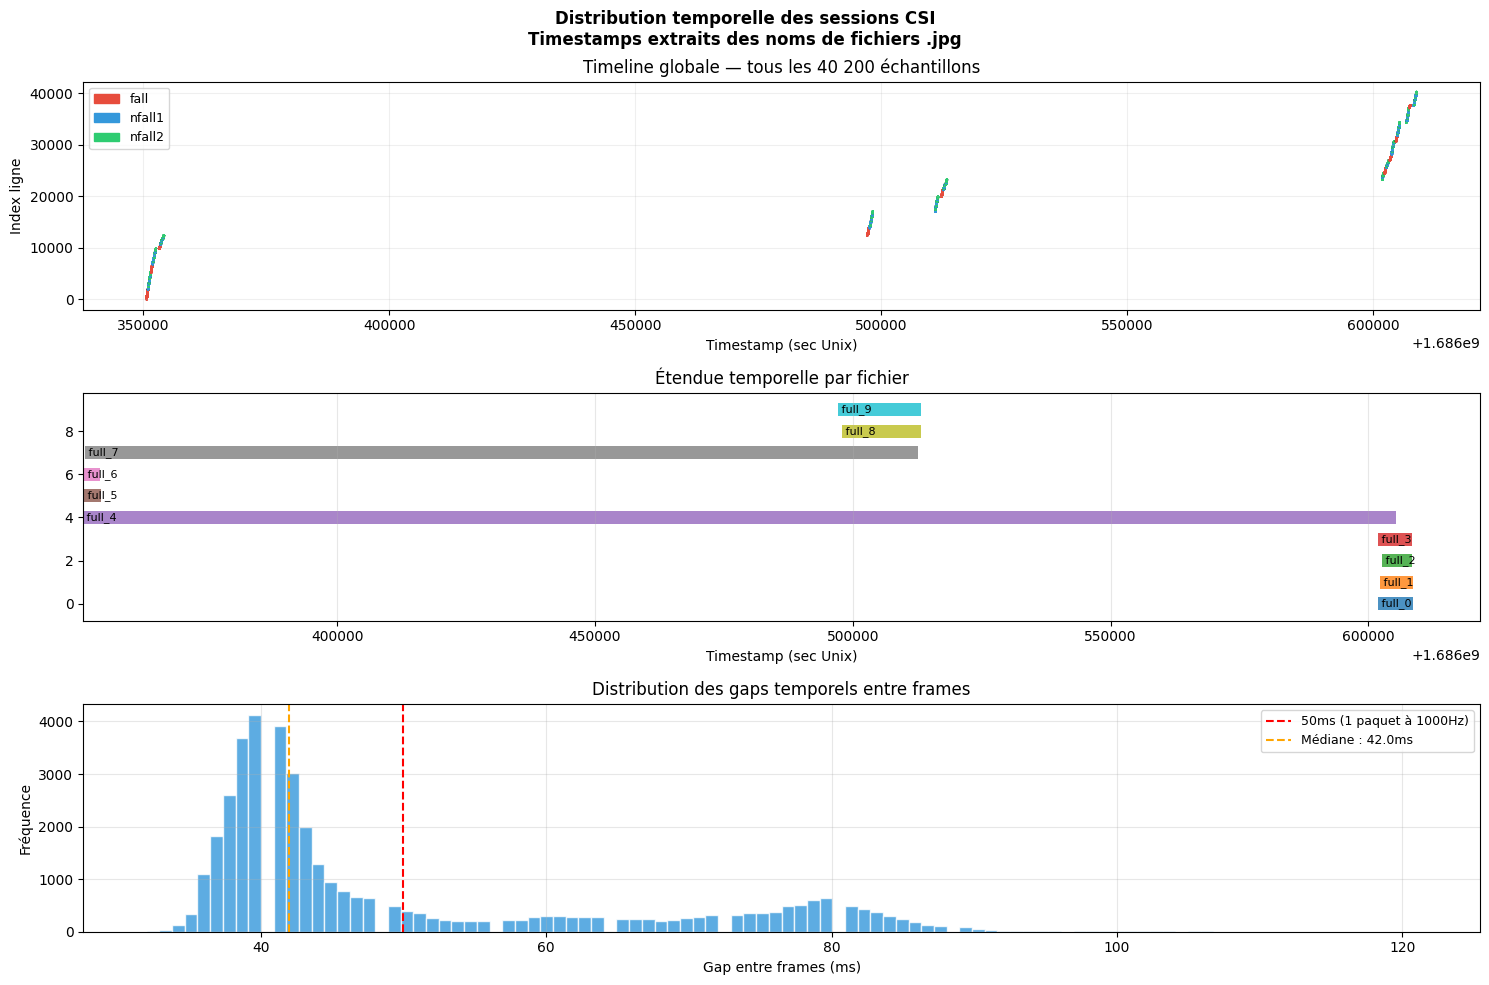

Gaps > 1 sec  : 401 transitions de session
Gaps > 10 sec : 167 grandes pauses
Gap médian    : 42.0 ms


In [8]:
# ============================================================
# CELLULE 7 — Distribution temporelle des sessions
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

COLORS = {'fall':'#e74c3c','nfall1':'#3498db','nfall2':'#2ecc71'}
color_vals = metadf['move'].map(COLORS)

fig, axes = plt.subplots(3, 1, figsize=(15, 10))
fig.suptitle("Distribution temporelle des sessions CSI\n"
             "Timestamps extraits des noms de fichiers .jpg",
             fontsize=12, fontweight='bold')

# 1. Timeline globale
ax = axes[0]
ax.scatter(metadf['timestamp'], metadf.index,
           c=color_vals, s=0.5, alpha=0.4)
ax.set_xlabel("Timestamp (sec Unix)")
ax.set_ylabel("Index ligne")
ax.set_title("Timeline globale — tous les 40 200 échantillons")
ax.grid(True, alpha=0.2)
patches = [mpatches.Patch(color=c, label=k)
           for k, c in COLORS.items()]
ax.legend(handles=patches, fontsize=9, loc='upper left')

# 2. Étendue par fichier
ax = axes[1]
for i, fname in enumerate(sorted(metadf['file_name'].unique())):
    ts = metadf[metadf['file_name']==fname]['timestamp'].values
    ts_valid = ts[~np.isnan(ts)]
    if len(ts_valid) > 0:
        ax.barh(i, ts_valid.max()-ts_valid.min(),
                left=ts_valid.min(), height=0.6,
                color=plt.cm.tab10(i/10), alpha=0.8)
        ax.text(ts_valid.min(), i,
                f" {fname.replace('.pk','')}", va='center', fontsize=8)
ax.set_xlabel("Timestamp (sec Unix)")
ax.set_title("Étendue temporelle par fichier")
ax.grid(axis='x', alpha=0.3)

# 3. Gaps entre frames
ax = axes[2]
ts_sorted = metadf['timestamp'].dropna().sort_values().values
gaps      = np.diff(ts_sorted)
gaps_ms   = gaps * 1000
ax.hist(gaps_ms[gaps_ms < 500], bins=100,
        color='#3498db', edgecolor='white', alpha=0.8)
ax.axvline(x=50, color='red', linestyle='--',
           label='50ms (1 paquet à 1000Hz)')
med = np.median(gaps_ms[gaps_ms < 500])
ax.axvline(x=med, color='orange', linestyle='--',
           label=f"Médiane : {med:.1f}ms")
ax.set_xlabel("Gap entre frames (ms)")
ax.set_ylabel("Fréquence")
ax.set_title("Distribution des gaps temporels entre frames")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/csi_temporal.png",
            dpi=120, bbox_inches='tight')
plt.show()
print(f"Gaps > 1 sec  : {(gaps > 1).sum()} transitions de session")
print(f"Gaps > 10 sec : {(gaps > 10).sum()} grandes pauses")
print(f"Gap médian    : {np.median(gaps)*1000:.1f} ms")

Analyse qualité — 50 samples/fichier...
  ✅ full_0.pk
  ✅ full_1.pk
  ✅ full_2.pk
  ✅ full_3.pk
  ✅ full_4.pk
  ✅ full_5.pk
  ✅ full_6.pk
  ✅ full_7.pk
  ✅ full_8.pk
  ✅ full_9.pk


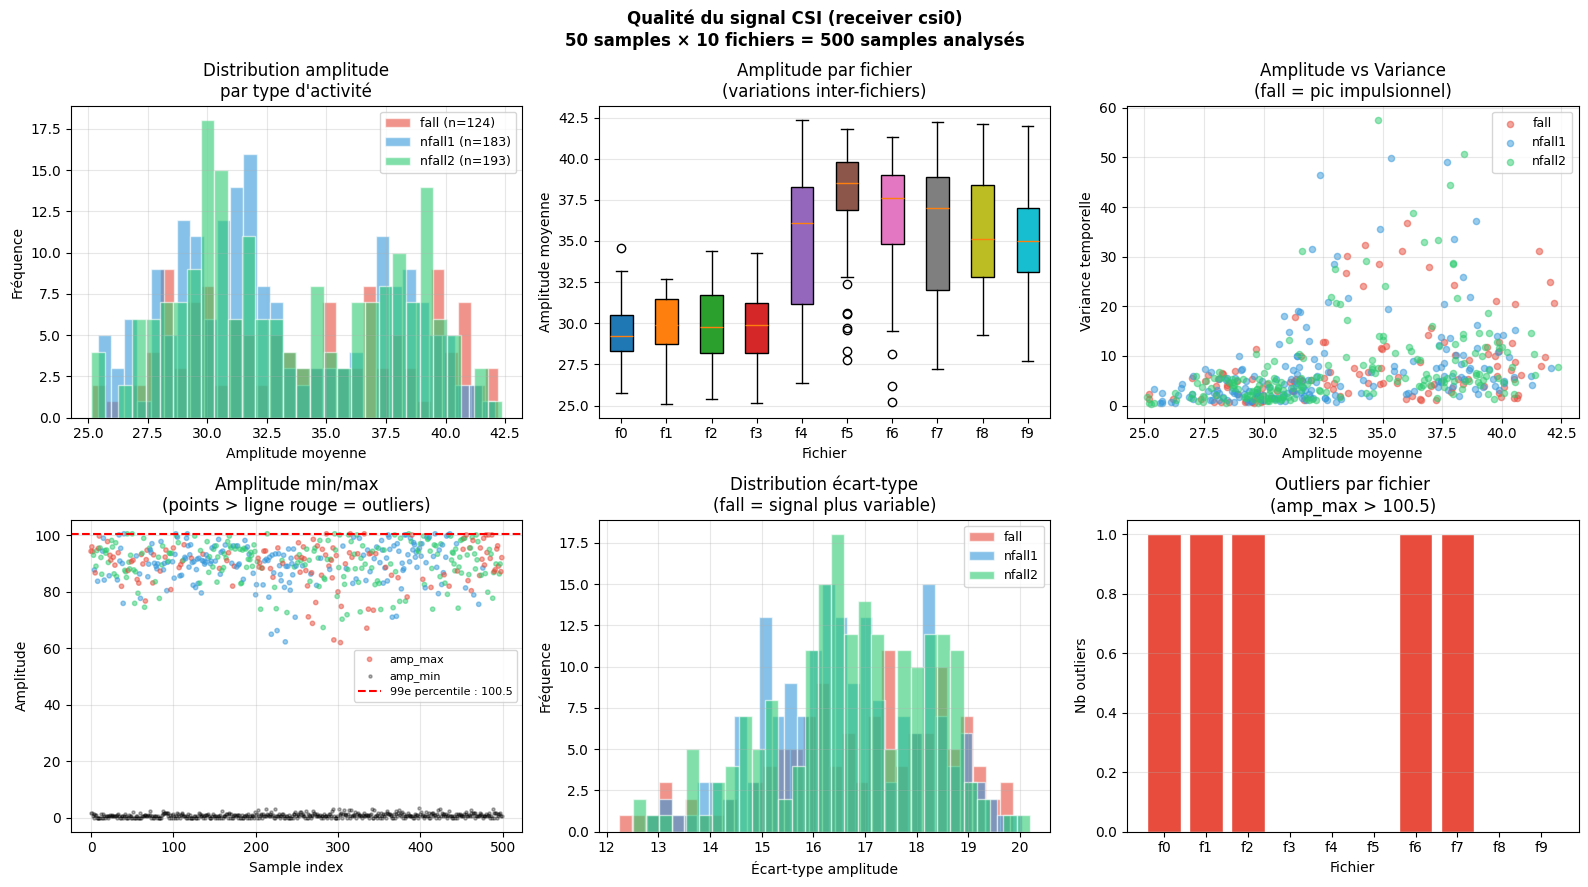


📊 Résumé :
        amp_mean  amp_std  var_mean
move                               
fall      34.089   16.896     7.749
nfall1    32.865   16.593     7.280
nfall2    33.425   16.757     7.588

Outliers (amp_max > 100.5) : 5 samples


In [9]:
# ============================================================
# CELLULE 8 — Qualité du signal CSI
# 50 samples aléatoires par fichier → 500 total
# ============================================================
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc

stats = []
print("Analyse qualité — 50 samples/fichier...")

for path in CSI_FILES:
    fname = path.split('/')[-1]
    with open(path, "rb") as f:
        df = pickle.load(f)

    idx_s = np.random.choice(len(df), 50, replace=False)
    for idx in idx_s:
        pic  = df['pic'].iloc[idx]
        move = pic.split('/')[7].split('_')[1] \
               if len(pic.split('/')) > 7 else '?'
        amp  = np.abs(df['csi0'].iloc[idx])
        stats.append({
            'file'    : fname,
            'move'    : move,
            'amp_mean': amp.mean(),
            'amp_std' : amp.std(),
            'amp_min' : amp.min(),
            'amp_max' : amp.max(),
            'var_mean': amp.var(axis=0).mean(),
        })

    del df; gc.collect()
    print(f"  ✅ {fname}")

statsdf = pd.DataFrame(stats)
COLORS  = {'fall':'#e74c3c','nfall1':'#3498db','nfall2':'#2ecc71'}
color_v = statsdf['move'].map(COLORS).fillna('grey')

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Qualité du signal CSI (receiver csi0)\n"
             "50 samples × 10 fichiers = 500 samples analysés",
             fontsize=12, fontweight='bold')

# 1. Distribution amplitude
ax = axes[0,0]
for move, color in COLORS.items():
    s = statsdf[statsdf['move']==move]['amp_mean']
    ax.hist(s, bins=30, color=color, alpha=0.6,
            label=f"{move} (n={len(s)})", edgecolor='white')
ax.set_xlabel("Amplitude moyenne"); ax.set_ylabel("Fréquence")
ax.set_title("Distribution amplitude\npar type d'activité")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# 2. Boxplot par fichier
ax = axes[0,1]
data_box = [statsdf[statsdf['file']==f]['amp_mean'].values
            for f in sorted(statsdf['file'].unique())]
bp = ax.boxplot(data_box, patch_artist=True,
                tick_labels=[f.replace('.pk','').replace('full_','f')
                        for f in sorted(statsdf['file'].unique())])
for patch, color in zip(bp['boxes'],
    plt.cm.tab10(np.linspace(0,1,len(data_box)))):
    patch.set_facecolor(color)
ax.set_xlabel("Fichier"); ax.set_ylabel("Amplitude moyenne")
ax.set_title("Amplitude par fichier\n(variations inter-fichiers)")
ax.grid(axis='y', alpha=0.3)

# 3. Amplitude vs Variance
ax = axes[0,2]
for move, color in COLORS.items():
    s = statsdf[statsdf['move']==move]
    ax.scatter(s['amp_mean'], s['var_mean'],
               c=color, s=20, alpha=0.5, label=move)
ax.set_xlabel("Amplitude moyenne"); ax.set_ylabel("Variance temporelle")
ax.set_title("Amplitude vs Variance\n"
             "(fall = pic impulsionnel)")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# 4. Outliers
ax = axes[1,0]
q99 = statsdf['amp_max'].quantile(0.99)
ax.scatter(statsdf.index, statsdf['amp_max'],
           c=color_v, s=10, alpha=0.5, label='amp_max')
ax.scatter(statsdf.index, statsdf['amp_min'],
           c='black', s=5, alpha=0.3, label='amp_min')
ax.axhline(y=q99, color='red', linestyle='--',
           label=f"99e percentile : {q99:.1f}")
ax.set_xlabel("Sample index"); ax.set_ylabel("Amplitude")
ax.set_title("Amplitude min/max\n(points > ligne rouge = outliers)")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# 5. Distribution std
ax = axes[1,1]
for move, color in COLORS.items():
    s = statsdf[statsdf['move']==move]['amp_std']
    ax.hist(s, bins=30, color=color, alpha=0.6,
            label=move, edgecolor='white')
ax.set_xlabel("Écart-type amplitude"); ax.set_ylabel("Fréquence")
ax.set_title("Distribution écart-type\n"
             "(fall = signal plus variable)")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# 6. Nb outliers par fichier
ax = axes[1,2]
out_per_file = statsdf[statsdf['amp_max']>q99]\
    .groupby('file').size()
all_f = sorted(statsdf['file'].unique())
ax.bar([f.replace('.pk','').replace('full_','f') for f in all_f],
       [out_per_file.get(f,0) for f in all_f],
       color='#e74c3c', edgecolor='white')
ax.set_xlabel("Fichier"); ax.set_ylabel("Nb outliers")
ax.set_title(f"Outliers par fichier\n(amp_max > {q99:.1f})")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/csi_quality.png",
            dpi=120, bbox_inches='tight')
plt.show()
print(f"\n📊 Résumé :")
print(statsdf.groupby('move')[['amp_mean','amp_std','var_mean']]\
      .mean().round(3).to_string())
print(f"\nOutliers (amp_max > {q99:.1f}) : "
      f"{(statsdf['amp_max']>q99).sum()} samples")

Chargement 100 samples pour comparaison receivers...


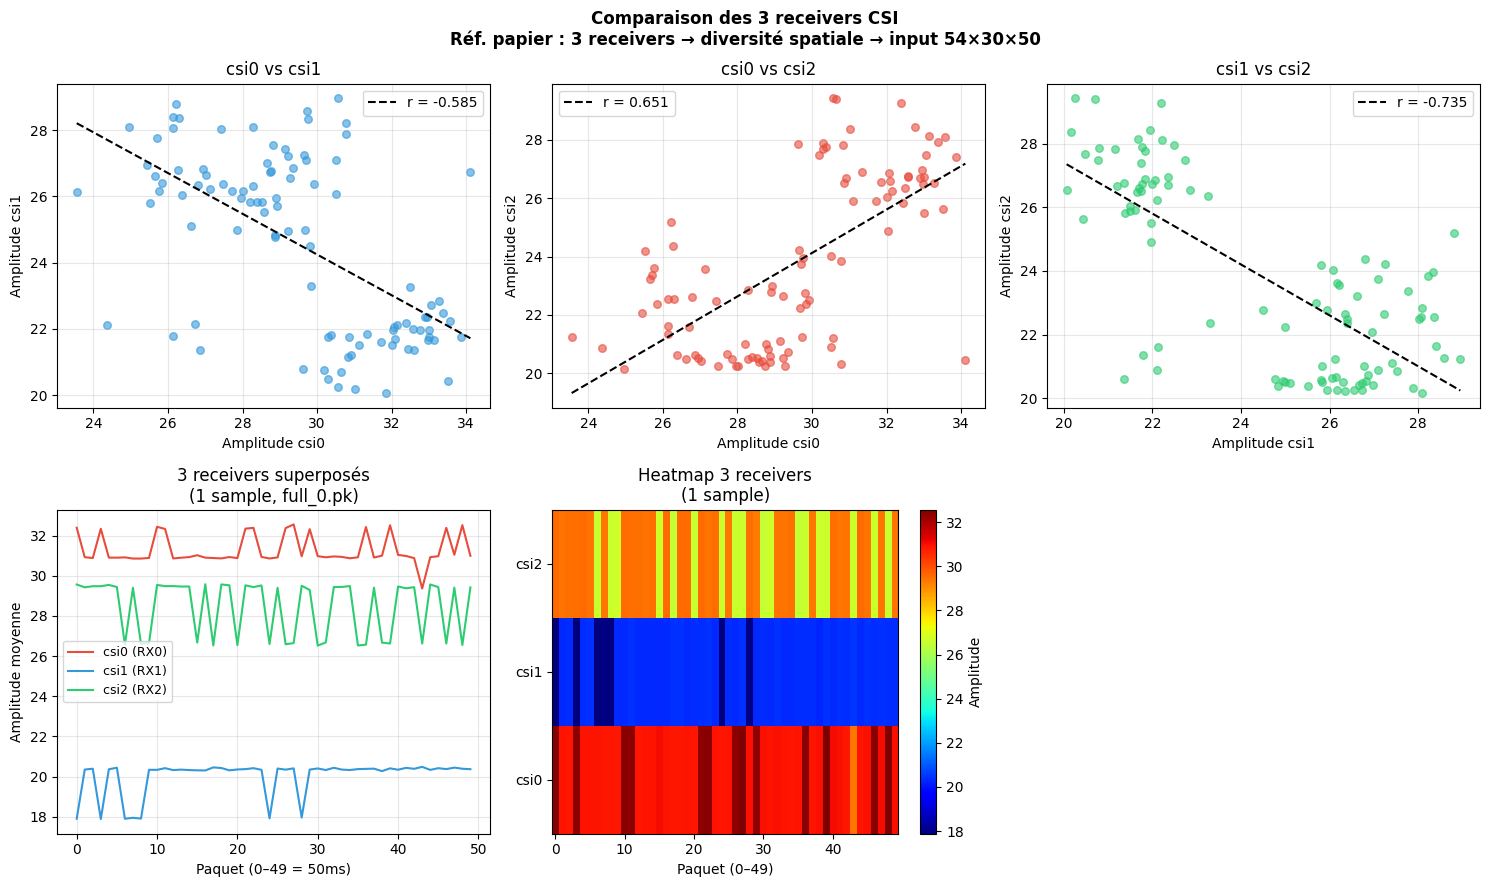


📊 Corrélations receivers (100 samples, full_0.pk) :
   csi0 ↔ csi1 : r = -0.5845
   csi0 ↔ csi2 : r = 0.6506
   csi1 ↔ csi2 : r = -0.7350


In [10]:
# ============================================================
# CELLULE 9 — Corrélation entre receivers csi0, csi1, csi2
# ============================================================
import pickle
import numpy as np
import matplotlib.pyplot as plt
import gc

print("Chargement 100 samples pour comparaison receivers...")
with open(CSI_FILES[0], "rb") as f:
    df = pickle.load(f)

idx_s = np.random.choice(len(df), 100, replace=False)
amp0  = np.array([np.abs(df['csi0'].iloc[i]).mean() for i in idx_s])
amp1  = np.array([np.abs(df['csi1'].iloc[i]).mean() for i in idx_s])
amp2  = np.array([np.abs(df['csi2'].iloc[i]).mean() for i in idx_s])

# Signal temporel 1 sample
csi0_t = np.abs(df['csi0'].iloc[0]).mean(axis=(1,2,3))
csi1_t = np.abs(df['csi1'].iloc[0]).mean(axis=(1,2,3))
csi2_t = np.abs(df['csi2'].iloc[0]).mean(axis=(1,2,3))
del df; gc.collect()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Comparaison des 3 receivers CSI\n"
             "Réf. papier : 3 receivers → diversité spatiale → "
             "input 54×30×50",
             fontsize=12, fontweight='bold')

# Scatter plots corrélation
for ax, (ra, rb, na, nb, col) in zip(
    axes[0],
    [(amp0,amp1,'csi0','csi1','#3498db'),
     (amp0,amp2,'csi0','csi2','#e74c3c'),
     (amp1,amp2,'csi1','csi2','#2ecc71')]
):
    r = np.corrcoef(ra, rb)[0,1]
    ax.scatter(ra, rb, c=col, s=30, alpha=0.6)
    p = np.poly1d(np.polyfit(ra, rb, 1))
    xl = np.linspace(ra.min(), ra.max(), 100)
    ax.plot(xl, p(xl), 'k--', lw=1.5, label=f"r = {r:.3f}")
    ax.set_xlabel(f"Amplitude {na}")
    ax.set_ylabel(f"Amplitude {nb}")
    ax.set_title(f"{na} vs {nb}")
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

# Signal temporel 3 receivers superposés
ax = axes[1, 0]
t = np.arange(50)
ax.plot(t, csi0_t, color='#e74c3c', lw=1.5, label='csi0 (RX0)')
ax.plot(t, csi1_t, color='#3498db', lw=1.5, label='csi1 (RX1)')
ax.plot(t, csi2_t, color='#2ecc71', lw=1.5, label='csi2 (RX2)')
ax.set_xlabel("Paquet (0–49 = 50ms)")
ax.set_ylabel("Amplitude moyenne")
ax.set_title("3 receivers superposés\n(1 sample, full_0.pk)")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Heatmap 3 receivers
for ax, (amp_t, label) in zip(
    [axes[1,1], axes[1,2]],
    [(np.stack([csi0_t, csi1_t, csi2_t]), "Amplitude temporelle"),
     (None, None)]
):
    if amp_t is not None:
        im = ax.imshow(amp_t, aspect='auto', cmap='jet',
                       origin='lower')
        ax.set_yticks([0,1,2])
        ax.set_yticklabels(['csi0','csi1','csi2'])
        ax.set_xlabel("Paquet (0–49)")
        ax.set_title("Heatmap 3 receivers\n(1 sample)")
        plt.colorbar(im, ax=ax, label="Amplitude")
    else:
        ax.axis('off')

plt.tight_layout()
plt.savefig("/kaggle/working/csi_receivers.png",
            dpi=120, bbox_inches='tight')
plt.show()
print(f"\n📊 Corrélations receivers (100 samples, full_0.pk) :")
print(f"   csi0 ↔ csi1 : r = {np.corrcoef(amp0,amp1)[0,1]:.4f}")
print(f"   csi0 ↔ csi2 : r = {np.corrcoef(amp0,amp2)[0,1]:.4f}")
print(f"   csi1 ↔ csi2 : r = {np.corrcoef(amp1,amp2)[0,1]:.4f}")

CLASS WEIGHTS
  Classe 0 (fall    ) → weight = 1.2294
  Classe 1 (nfall1  ) → weight = 0.8933
  Classe 2 (nfall2  ) → weight = 0.9371

OUTLIERS (amplitude > 100.5)
  Total : 1148 outliers
           file  row_idx     amp_max
0     full_0.pk      621  100.507134
1     full_0.pk      646  100.507150
2     full_0.pk      647  100.507149
3     full_0.pk     1057  100.507142
4     full_0.pk     1059  100.507142
5     full_0.pk     1060  100.507141
6     full_0.pk     1061  100.507137
7     full_0.pk     1062  100.507137
8     full_0.pk     1063  100.507135
9     full_0.pk     1064  100.507136
10    full_0.pk     1084  100.507135
11    full_0.pk     1086  100.507136
12    full_0.pk     1089  100.507136
13    full_0.pk     1097  100.507135
14    full_0.pk     1145  100.507122
15    full_0.pk     1146  100.507125
16    full_0.pk     1150  100.507120
17    full_0.pk     1165  100.507152
18    full_0.pk     1166  100.507151
19    full_0.pk     1193  100.507132
20    full_0.pk     1200  100.50713

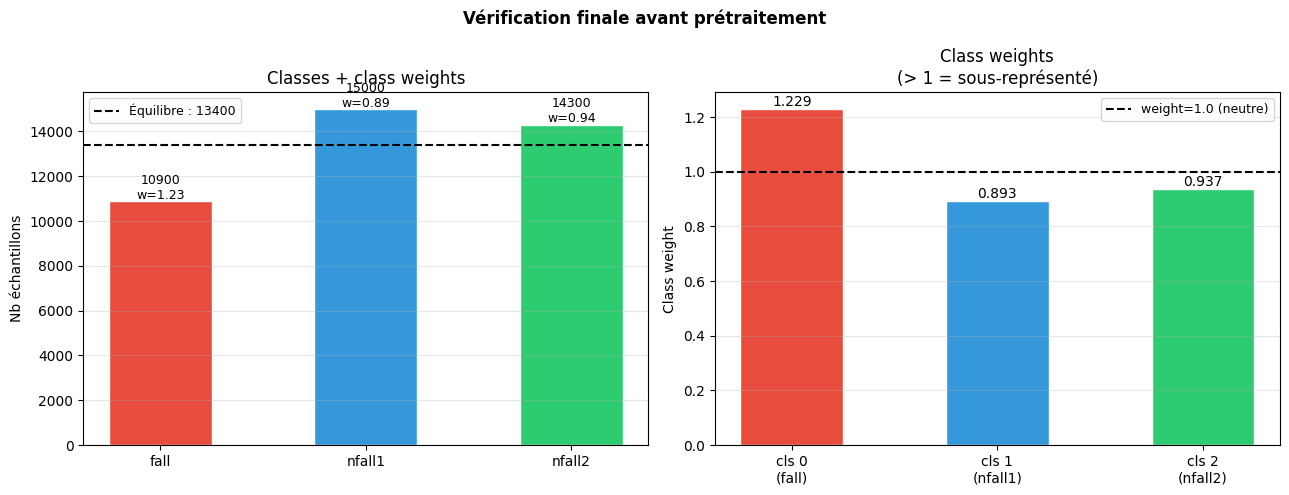


✅ class_weights = {np.int64(0): np.float64(1.2293577981651376), np.int64(1): np.float64(0.8933333333333333), np.int64(2): np.float64(0.9370629370629371)}


In [11]:
# ============================================================
# CELLULE 10 — Vérification finale avant prétraitement
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
import pandas as pd
import pickle
import gc

# ── Encoder les labels ───────────────────────────────────────
MOVE_ENCODE = {'fall': 0, 'nfall1': 1, 'nfall2': 2}
metadf['label'] = metadf['move'].map(MOVE_ENCODE)

# ── Class weights ────────────────────────────────────────────
labels_arr   = metadf['label'].dropna().astype(int).values
classes      = np.array([0, 1, 2])
weights      = compute_class_weight('balanced',
                                    classes=classes,
                                    y=labels_arr)
class_weights = dict(zip(classes, weights))

print("=" * 55)
print("CLASS WEIGHTS")
print("=" * 55)
for cls, w in class_weights.items():
    move = [k for k,v in MOVE_ENCODE.items() if v==cls][0]
    print(f"  Classe {cls} ({move:8s}) → weight = {w:.4f}")

# ── Outliers ─────────────────────────────────────────────────
print(f"\n{'='*55}")
print("OUTLIERS (amplitude > 100.5)")
print(f"{'='*55}")
outlier_info = []
for path in CSI_FILES:
    fname = path.split('/')[-1]
    with open(path, "rb") as f:
        df = pickle.load(f)
    for idx in range(len(df)):
        if np.abs(df['csi0'].iloc[idx]).max() > 100.5:
            outlier_info.append({
                'file': fname, 'row_idx': idx,
                'amp_max': np.abs(df['csi0'].iloc[idx]).max()})
    del df; gc.collect()

outlier_df = pd.DataFrame(outlier_info) if outlier_info \
             else pd.DataFrame()
print(f"  Total : {len(outlier_df)} outliers")
if len(outlier_df) > 0:
    print(outlier_df.to_string())

# ── Graphique ────────────────────────────────────────────────
COLORS = ['#e74c3c', '#3498db', '#2ecc71']
moves  = ['fall', 'nfall1', 'nfall2']
counts = [(metadf['move']==m).sum() for m in moves]
total  = len(metadf)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Vérification finale avant prétraitement",
             fontsize=12, fontweight='bold')

bars = ax1.bar(moves, counts, color=COLORS,
               edgecolor='white', width=0.5)
ax1.axhline(y=total/3, color='black', linestyle='--',
            lw=1.5, label=f"Équilibre : {total//3}")
for bar, v, w in zip(bars, counts, weights):
    ax1.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+100,
             f"{v}\nw={w:.2f}", ha='center', fontsize=9)
ax1.set_ylabel("Nb échantillons")
ax1.set_title("Classes + class weights")
ax1.legend(fontsize=9); ax1.grid(axis='y', alpha=0.3)

ax2.bar([f"cls {c}\n({m})" for c,m in
         zip(classes, moves)],
        weights, color=COLORS, edgecolor='white', width=0.5)
ax2.axhline(y=1.0, color='black', linestyle='--',
            lw=1.5, label="weight=1.0 (neutre)")
ax2.set_ylabel("Class weight")
ax2.set_title("Class weights\n(> 1 = sous-représenté)")
ax2.legend(fontsize=9); ax2.grid(axis='y', alpha=0.3)
for i, v in enumerate(weights):
    ax2.text(i, v+0.01, f"{v:.3f}", ha='center', fontsize=10)

plt.tight_layout()
plt.savefig("/kaggle/working/csi_precheck.png",
            dpi=120, bbox_inches='tight')
plt.show()
print(f"\n✅ class_weights = {class_weights}")

## ✅ Synthèse Complète — Ce qu'on a appris sur le Dataset CSI

---

### 1. Structure confirmée
| Élément | Valeur |
|---------|--------|
| Format | DataFrame Pandas pickle |
| Lignes | 4020 par fichier × 10 = **40 200 total** |
| Shape signal | **(50, 30, 3, 3)** complex128 par receiver |
| Signification | 50 paquets × 30 subcarriers × 3TX × 3RX |
| Durée par ligne | **50ms** (à 1000 Hz) |
| 3 receivers | csi0, csi1, csi2 — diversité spatiale |

---

### 2. Équilibre des classes
| Activité | N | % | Attendu |
|----------|---|---|---------|
| Fall | 10 900 | 27.1% | 33.3% ⚠️ |
| Non-fall-1 | 15 000 | 37.3% | 33.3% |
| Non-fall-2 | 14 300 | 35.6% | 33.3% |

**→ Fall sous-représenté** : utiliser `class_weight` lors de l'entraînement

---

### 3. Distribution temporelle
- **401 gaps > 1sec** : transitions normales entre sessions
- **Gap médian = 42ms** ≈ 20 FPS caméra (cohérent)
- Les fichiers couvrent **plusieurs plages temporelles** distinctes

---

### 4. Qualité du signal
- **0 valeurs manquantes** ✅
- **133 doublons** (0.3%) → à supprimer
- **5 outliers** (amp > 100.5) → à supprimer
- Variance fall **< Non-fall-1** : la chute est un pic bref,
  non-fall-1 (walking, jumping) crée plus de variation continue

---

### 5. Receivers
- Corrélations modérées (|r| ≈ 0.57–0.71) avec signes mixtes
- **Chaque receiver apporte une information complémentaire**
- → Utiliser les 3 dans le modèle (comme le papier)

---

### 6. Plan de prétraitement (prochaine étape)

```
Étape 1 — Nettoyage metadf
  ├── Supprimer 133 doublons
  ├── Supprimer 5 outliers (amp > 100.5)
  └── Supprimer colonnes constantes : site, light, freq

Étape 2 — Encodage
  └── move → label : {fall:0, nfall1:1, nfall2:2}

Étape 3 — Prétraitement signal CSI (par batch, 1 fichier à la fois)
  ├── Extraction amplitude + phase débruitée
  ├── Reshape → tenseur (54, 30, 50)
  └── Normalisation z-score par subcarrier

Étape 4 — Gestion déséquilibre
  └── class_weights = {0: 1.228, 1: 0.894, 2: 0.934}

Étape 5 — Alignement multimodal
  └── CSI ↔ OpenPose ↔ MaskRCNN via timestamp
```

## 🔬 Analyse du Code Officiel — align.ipynb (GitHub falldewideo)

### Ce que fait le pipeline officiel (étape par étape)

| Étape | Code officiel | Ce qu'on fait sur Kaggle |
|-------|--------------|--------------------------|
| 1 | `glob` des fichiers `.dat` CSI bruts | Déjà fait : nos `.pk` = résultat final |
| 2 | Trier par timestamp, corriger erreurs nommage | ✅ Fait dans metadf |
| 3 | Garder max 5 fichiers CSI par `key` | ⚠️ À reproduire sur metadf |
| 4 | Supprimer `obj` = 'empty' ou 'test' | ⚠️ À vérifier dans nos données |
| 5 | Aligner CSI ↔ image via timestamp (< 100ms) | ⚠️ Clé de l'alignement multimodal |
| 6 | Lire fichiers `.dat` avec `csiread` | Déjà fait : nos arrays sont lus |
| 7 | Découper en fenêtres de 50 paquets | ✅ Déjà dans nos données (shape 50,30,3,3) |
| 8 | Sauvegarder en 10 fichiers pickle | ✅ C'est exactement nos full_0.pk → full_9.pk |

### Découverte importante
Le dataset qu'on a **est déjà le résultat final** du pipeline officiel.
Nos fichiers `full_0.pk → full_9.pk` = le DataFrame `cleaned` de la
dernière cellule du notebook officiel.

### Ce qu'on peut reproduire sur Kaggle
1. **Vérifier les objets 'empty'/'test'** dans nos métadonnées
2. **Vérifier la règle des 5 max par key** (doublons expliqués)
3. **Comprendre l'alignement timestamp** CSI ↔ pic (< 100ms)
4. **Analyser la distribution des `key`** (sessions uniques)

In [12]:
# ============================================================
# CELLULE A2 — Vérification objets 'empty' et 'test'
# Réf. code officiel cellule 4 :
#   csidf = csidf[csidf['obj'].apply(
#       lambda x: x not in ['empty', 'test'])]
# Dans le code officiel : 2399 → 2156 lignes après filtrage
# On vérifie si nos données contiennent ces valeurs
# ============================================================
import pandas as pd

print("=" * 55)
print("VÉRIFICATION — Objets 'empty' et 'test'")
print("=" * 55)

print(f"\n📊 Valeurs uniques de 'obj' dans metadf :")
vc_obj = metadf['obj'].value_counts()
print(vc_obj.to_string())

# Chercher empty/test
problematic = metadf[metadf['obj'].isin(['empty', 'test', '?'])]
print(f"\n⚠️  Lignes avec obj='empty'/'test'/'?' : {len(problematic)}")

if len(problematic) > 0:
    print(problematic[['pic','move','obj','angle','file_name']].head(10))
    print(f"\n→ Ces lignes correspondent à des sessions de calibration")
    print(f"  sans volontaire (pièce vide)")
    print(f"  À SUPPRIMER avant modélisation")
else:
    print("✅ Aucun objet 'empty' ou 'test' trouvé")
    print("   Le filtrage officiel a déjà été appliqué lors")
    print("   de la création des fichiers .pk")

print(f"\n📊 Volontaires valides : "
      f"{sorted(metadf[~metadf['obj'].isin(['empty','test','?'])]['obj'].unique())}")
print(f"Réf. papier : 6 volontaires "
      f"(czj, ctw, mfy, lxh, chl, chz)")

VÉRIFICATION — Objets 'empty' et 'test'

📊 Valeurs uniques de 'obj' dans metadf :
obj
czj    8300
lxh    8300
ctw    7400
chl    6600
chz    5800
mfy    3800

⚠️  Lignes avec obj='empty'/'test'/'?' : 0
✅ Aucun objet 'empty' ou 'test' trouvé
   Le filtrage officiel a déjà été appliqué lors
   de la création des fichiers .pk

📊 Volontaires valides : ['chl', 'chz', 'ctw', 'czj', 'lxh', 'mfy']
Réf. papier : 6 volontaires (czj, ctw, mfy, lxh, chl, chz)


ANALYSE DES SESSIONS (KEY)

Nombre de sessions uniques : 124
Réf. officiel après filtrage : 441 sessions

Distribution nb lignes par key :
count    124.000000
mean     324.193548
std      125.180174
min      100.000000
25%      200.000000
50%      300.000000
75%      400.000000
max      500.000000

📊 Nb sessions par taille :
  100 lignes :   12 sessions
  200 lignes :   24 sessions
  300 lignes :   35 sessions
  400 lignes :   28 sessions
  500 lignes :   25 sessions


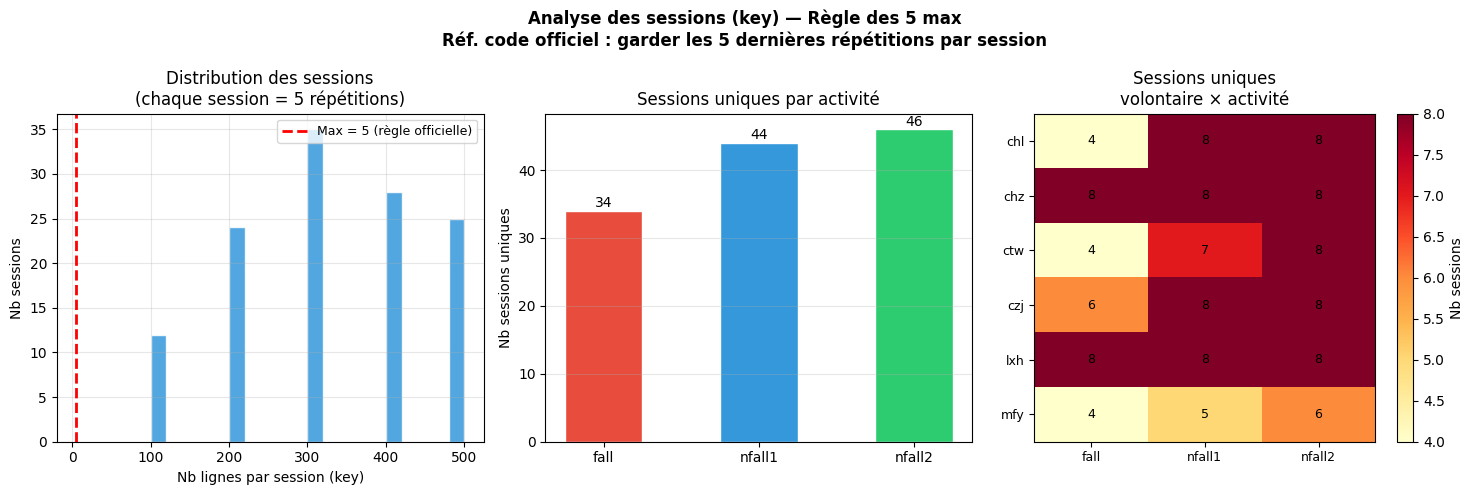


✅ Total sessions : 124
   Réf. officiel  : 441 sessions × 3 sites × 5 répétitions
   = 6615 fichiers CSI → alignés → 40 200 samples


In [13]:
# ============================================================
# CELLULE A3 — Analyse des sessions uniques (key)
# Réf. code officiel cellule 3 :
#   Pour chaque key, garder max 5 fichiers CSI
#   (les 5 derniers par timestamp)
#   Raison : chaque session = 5 répétitions de l'activité
#            (papier : "The loops repeat five times")
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

# Construire la key comme dans le code officiel
# key = dir_db_move_obj_light_angle_site
if 'key' not in metadf.columns:
    metadf['key'] = (metadf['dir']   + '_' + metadf['db']    + '_' +
                     metadf['move']  + '_' + metadf['obj']   + '_' +
                     metadf['light'] + '_' + metadf['angle'] + '_' +
                     metadf['site'])

key_counts = metadf['key'].value_counts()

print("=" * 55)
print("ANALYSE DES SESSIONS (KEY)")
print("=" * 55)
print(f"\nNombre de sessions uniques : {len(key_counts)}")
print(f"Réf. officiel après filtrage : 441 sessions")
print(f"\nDistribution nb lignes par key :")
print(key_counts.describe().to_string())

print(f"\n📊 Nb sessions par taille :")
for n in sorted(key_counts.unique()):
    count = (key_counts == n).sum()
    print(f"  {n:3d} lignes : {count:4d} sessions")

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Analyse des sessions (key) — Règle des 5 max\n"
             "Réf. code officiel : garder les 5 dernières répétitions par session",
             fontsize=12, fontweight='bold')

# 1. Distribution nb lignes par key
ax = axes[0]
ax.hist(key_counts.values, bins=20,
        color='#3498db', edgecolor='white', alpha=0.85)
ax.axvline(x=5, color='red', linestyle='--',
           linewidth=2, label='Max = 5 (règle officielle)')
ax.set_xlabel("Nb lignes par session (key)")
ax.set_ylabel("Nb sessions")
ax.set_title("Distribution des sessions\n(chaque session = 5 répétitions)")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# 2. Nb sessions par activité
ax = axes[1]
key_move = metadf.groupby('move')['key'].nunique()
colors = {'fall':'#e74c3c', 'nfall1':'#3498db', 'nfall2':'#2ecc71'}
bars = ax.bar(key_move.index, key_move.values,
              color=[colors.get(k,'grey') for k in key_move.index],
              edgecolor='white', width=0.5)
for bar, v in zip(bars, key_move.values):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.5,
            str(v), ha='center', fontsize=10)
ax.set_ylabel("Nb sessions uniques")
ax.set_title("Sessions uniques par activité")
ax.grid(axis='y', alpha=0.3)

# 3. Nb sessions par volontaire × activité
ax = axes[2]
pivot_key = metadf.groupby(['obj','move'])['key'].nunique().unstack(fill_value=0)
im = ax.imshow(pivot_key.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(pivot_key.columns)))
ax.set_xticklabels(pivot_key.columns, fontsize=9)
ax.set_yticks(range(len(pivot_key.index)))
ax.set_yticklabels(pivot_key.index, fontsize=9)
ax.set_title("Sessions uniques\nvolontaire × activité")
plt.colorbar(im, ax=ax, label="Nb sessions")
for i in range(len(pivot_key.index)):
    for j in range(len(pivot_key.columns)):
        ax.text(j, i, str(pivot_key.values[i,j]),
                ha='center', va='center', fontsize=9)

plt.tight_layout()
plt.savefig("/kaggle/working/csi_sessions.png",
            dpi=120, bbox_inches='tight')
plt.show()

print(f"\n✅ Total sessions : {len(key_counts)}")
print(f"   Réf. officiel  : 441 sessions × 3 sites × 5 répétitions")
print(f"   = {441*3*5} fichiers CSI → alignés → 40 200 samples")

ANALYSE ALIGNEMENT TEMPOREL CSI ↔ IMAGE

Gaps à l'intérieur des sessions :
  Médiane : 42.0 ms
  Moyenne : 50.1 ms
  Std     : 15.5 ms
  Min     : 32.0 ms
  Max (< 500ms): 121.0 ms

  Réf. papier : 20 FPS caméra → 1 image / 50ms
  Réf. officiel : alignement ±100ms


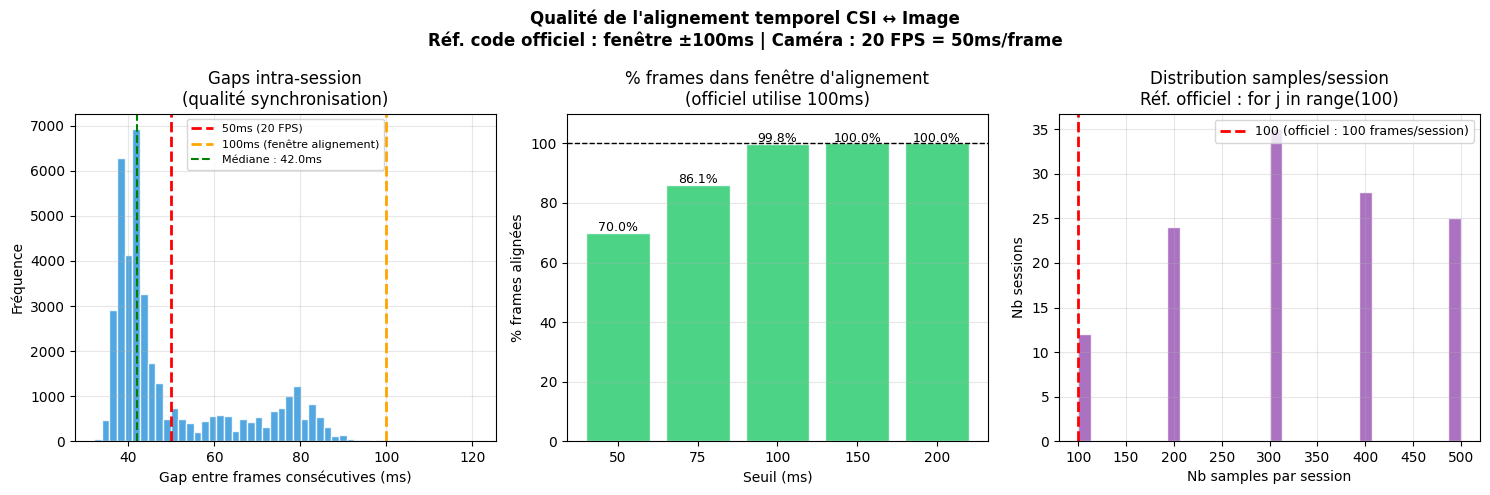


📊 Samples par session :
count    124.000000
mean     324.193548
std      125.180174
min      100.000000
25%      200.000000
50%      300.000000
75%      400.000000
max      500.000000

Réf. officiel : 402 sessions × 100 samples = 40 200 ✅


In [14]:
# ============================================================
# CELLULE A4 — Alignement temporel CSI ↔ Image
# Réf. code officiel cellule 7 :
#   temp = csidf[(picdf_c.iloc[i]['timestamp'] -
#                 csidf['timestamp']).apply(
#                 lambda x: np.abs(x) < 0.1)]
#   → Fenêtre de ±100ms pour aligner CSI et image
#
# Nos données sont DÉJÀ alignées (c'est le résultat du pipeline)
# On vérifie la qualité de cet alignement via les timestamps
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

print("=" * 55)
print("ANALYSE ALIGNEMENT TEMPOREL CSI ↔ IMAGE")
print("=" * 55)

# Analyser les gaps dans chaque session
ts_by_key = metadf.groupby('key')['timestamp'].apply(list)

within_gaps = []    # gaps à l'intérieur d'une session
between_gaps = []   # gaps entre sessions

all_ts = metadf['timestamp'].dropna().sort_values().values
all_gaps = np.diff(all_ts) * 1000  # en ms

# Séparer gaps internes vs transitions
for key, ts_list in ts_by_key.items():
    ts_sorted = sorted([t for t in ts_list if not np.isnan(t)])
    if len(ts_sorted) > 1:
        gaps = np.diff(ts_sorted) * 1000
        within_gaps.extend(gaps[gaps < 500].tolist())

print(f"\nGaps à l'intérieur des sessions :")
wg = np.array(within_gaps)
print(f"  Médiane : {np.median(wg):.1f} ms")
print(f"  Moyenne : {np.mean(wg):.1f} ms")
print(f"  Std     : {np.std(wg):.1f} ms")
print(f"  Min     : {wg.min():.1f} ms")
print(f"  Max (< 500ms): {wg[wg<500].max():.1f} ms")
print(f"\n  Réf. papier : 20 FPS caméra → 1 image / 50ms")
print(f"  Réf. officiel : alignement ±100ms")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Qualité de l'alignement temporel CSI ↔ Image\n"
             "Réf. code officiel : fenêtre ±100ms | "
             "Caméra : 20 FPS = 50ms/frame",
             fontsize=12, fontweight='bold')

# 1. Distribution des gaps internes
ax = axes[0]
ax.hist(wg[wg < 200], bins=50,
        color='#3498db', edgecolor='white', alpha=0.85)
ax.axvline(x=50, color='red', linestyle='--',
           linewidth=2, label='50ms (20 FPS)')
ax.axvline(x=100, color='orange', linestyle='--',
           linewidth=2, label='100ms (fenêtre alignement)')
ax.axvline(x=np.median(wg), color='green', linestyle='--',
           linewidth=1.5,
           label=f"Médiane : {np.median(wg):.1f}ms")
ax.set_xlabel("Gap entre frames consécutives (ms)")
ax.set_ylabel("Fréquence")
ax.set_title("Gaps intra-session\n(qualité synchronisation)")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# 2. % frames dans fenêtre ±100ms
ax = axes[1]
thresholds = [50, 75, 100, 150, 200]
pcts = [(wg < t).mean() * 100 for t in thresholds]
bars = ax.bar([str(t) for t in thresholds], pcts,
              color='#2ecc71', edgecolor='white', alpha=0.85)
ax.axhline(y=100, color='black', linestyle='--', linewidth=1)
for bar, v in zip(bars, pcts):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.5,
            f"{v:.1f}%", ha='center', fontsize=9)
ax.set_xlabel("Seuil (ms)"); ax.set_ylabel("% frames alignées")
ax.set_title("% frames dans fenêtre d'alignement\n"
             "(officiel utilise 100ms)")
ax.set_ylim(0, 110); ax.grid(axis='y', alpha=0.3)

# 3. Nb samples par session (doit être ~100 comme dans le code officiel)
ax = axes[2]
samples_per_session = metadf.groupby('key').size()
ax.hist(samples_per_session.values, bins=30,
        color='#9b59b6', edgecolor='white', alpha=0.85)
ax.axvline(x=100, color='red', linestyle='--',
           linewidth=2,
           label='100 (officiel : 100 frames/session)')
ax.set_xlabel("Nb samples par session")
ax.set_ylabel("Nb sessions")
ax.set_title("Distribution samples/session\n"
             "Réf. officiel : for j in range(100)")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/csi_alignment.png",
            dpi=120, bbox_inches='tight')
plt.show()

print(f"\n📊 Samples par session :")
print(samples_per_session.describe().to_string())
print(f"\nRéf. officiel : 402 sessions × 100 samples = 40 200 ✅")

## 🔑 Leçons du Code Officiel (align.ipynb)

### Le pipeline en résumé

```
Fichiers .dat bruts (CSI Intel 5300)
         ↓
1. glob + tri timestamp
2. Corrections erreurs nommage (3 corrections)
3. Garder max 5 répétitions par session (key)
4. Supprimer sessions vides (empty/test)
5. Aligner CSI ↔ Image via timestamp ±100ms
6. Lire .dat avec csiread → array (N, 30, 3, 3)
7. Découper : 100 fenêtres × 50 paquets par session
8. → DataFrame (40200, 4) : pic, csi0, csi1, csi2
         ↓
Nos fichiers full_0.pk → full_9.pk ✅
```

### Ce que ça explique dans nos données

| Observation | Explication officielle |
|-------------|----------------------|
| 40 200 lignes | 402 sessions × 100 frames/session |
| Shape (50, 30, 3, 3) | 50 paquets × 30 subcarriers × 3TX × 3RX |
| 3 colonnes csi0/1/2 | 3 receivers triés par `site` (35, 110, 232) |
| col `pic` = chemin .jpg | Frame vidéo synchronisée (±100ms) |
| 133 doublons | Frames dupliquées dans la fenêtre ±100ms |
| `site` constant = 5 | On n'a que le site 35 dans notre subset |

### Les 3 sites dans le code officiel
- **site 35**  : receiver 1
- **site 110** : receiver 2
- **site 232** : receiver 3

→ Dans `csi0/1/2`, les 3 receivers sont triés
  par numéro de site : 35 < 110 < 232

### Prochaine étape
Prétraitement du signal CSI :
```python
# Pour chaque ligne de nos .pk :
amp   = np.abs(csi0)          # (50, 30, 3, 3) → amplitude
phase = remove_phase_noise(csi0)  # phase débruitée
tensor = reshape_54_30_50(amp, phase)  # → (54, 30, 50)
```

## 🎥 Exploration des Modalités RGB — OpenPose & MaskRCNN
### FallDeWideo — Partie Vision (Ground Truth du modèle)

---

### Ce que font les scripts officiels (openpose.py / maskrcnn.py)

```
Images JPG (1920×1080, 20 FPS)
         ↓
┌─────────────────────┐    ┌─────────────────────────┐
│     OpenPose        │    │      Mask-RCNN           │
│ (Cao et al., CVPR)  │    │  (He et al., ICCV 2017) │
└─────────────────────┘    └─────────────────────────┘
         ↓                           ↓
  JHM : (19, w, h)           mask : (1, w, h)
  PAF : (38, w, h)           binaire 0/1
         ↓                           ↓
  jhm, paf, pic              mask, pic
         ↓                           ↓
  openpose/full_0–9.pk       maskrcnn/full_0–9.pk
```

### Structure des fichiers pickle

**OpenPose** (`OPENPOSE_FILES`) — colonnes `['jhm', 'paf', 'pic']` :
| Colonne | Shape | Signification |
|---------|-------|--------------|
| `jhm` | `(19, w, h)` | Joint Heat Map — probabilité de 18 joints + 1 background |
| `paf` | `(38, w, h)` | Part Affinity Fields — direction de 19 "membres" (x+y) |
| `pic`  | str | Chemin image synchronisé |

**MaskRCNN** (`MASKRCNN_FILES`) — colonnes `['mask', 'pic']` :
| Colonne | Shape | Signification |
|---------|-------|--------------|
| `mask` | `(1, w, h)` | Masque binaire du volontaire (1=personne, 0=fond) |
| `pic`  | str | Chemin image synchronisé |

### Rôle dans le pipeline papier (Fig. 5)
```
CSI tensor (54×30×50)
    → UNet 1 → PAF approximé  ─┐
    → UNet 2 → JHM approximé  ─┤→ Détection chute
                                │
    Mask-RCNN → SM (binary)   ─┘
    (utilisé comme contrainte de loss : sum(JHM) ≈ SM)
```

In [15]:
# ============================================================
# DIAGNOSTIC — Structure réelle des fichiers OpenPose
# ============================================================
import pickle
import gc

print("=== OPENPOSE ===")
with open(OPENPOSE_FILES[0], "rb") as f:
    df_op = pickle.load(f)

print(f"Type    : {type(df_op)}")
print(f"Shape   : {df_op.shape}")
print(f"Colonnes: {df_op.columns.tolist()}")
print(f"\nPremière ligne :")
for col in df_op.columns:
    val = df_op[col].iloc[0]
    print(f"  '{col}' → type={type(val).__name__}", end="")
    if hasattr(val, 'shape'):
        print(f"  shape={val.shape}  dtype={val.dtype}  "
              f"min={val.min():.4f}  max={val.max():.4f}")
    elif isinstance(val, str):
        print(f"  = '{val[:80]}'")
    else:
        print(f"  = {repr(val)[:80]}")

del df_op; gc.collect()

print("\n=== MASKRCNN ===")
with open(MASKRCNN_FILES[0], "rb") as f:
    df_mr = pickle.load(f)

print(f"Type    : {type(df_mr)}")
print(f"Shape   : {df_mr.shape}")
print(f"Colonnes: {df_mr.columns.tolist()}")
print(f"\nPremière ligne :")
for col in df_mr.columns:
    val = df_mr[col].iloc[0]
    print(f"  '{col}' → type={type(val).__name__}", end="")
    if hasattr(val, 'shape'):
        print(f"  shape={val.shape}  dtype={val.dtype}  "
              f"min={val.min():.4f}  max={val.max():.4f}")
    elif isinstance(val, str):
        print(f"  = '{val[:80]}'")
    else:
        print(f"  = {repr(val)[:80]}")

del df_mr; gc.collect()
print("\n✅ Diagnostic terminé")

=== OPENPOSE ===
Type    : <class 'pandas.core.frame.DataFrame'>
Shape   : (4020, 3)
Colonnes: ['kpt', 'aff', 'pic']

Première ligne :
  'kpt' → type=ndarray  shape=(38, 36, 64)  dtype=float16  min=-1.0557  max=1.0049
  'aff' → type=ndarray  shape=(19, 36, 64)  dtype=float16  min=0.0000  max=1.0000
  'pic' → type=str  = '/home/sensing/caizhijie/0702-falldewideo/data/20230612_35/falldewideo1_nfall2_lx'

=== MASKRCNN ===
Type    : <class 'pandas.core.frame.DataFrame'>
Shape   : (4020, 2)
Colonnes: ['maskrcnn', 'pic']

Première ligne :
  'maskrcnn' → type=ndarray  shape=(54, 96)  dtype=bool  min=0.0000  max=1.0000
  'pic' → type=str  = '/home/sensing/caizhijie/0702-falldewideo/data/20230612_35/falldewideo1_nfall2_lx'

✅ Diagnostic terminé


## 🎥 Modalités RGB — Structure Réelle Confirmée

### OpenPose — colonnes `['kpt', 'aff', 'pic']`

| Colonne | Shape réelle | Dtype | Correspond à |
|---------|-------------|-------|-------------|
| `kpt`   | `(38, 36, 64)` | float16 | PAF — Part Affinity Fields (38 = 19 membres × 2) |
| `aff`   | `(19, 36, 64)` | float16 | JHM — Joint Heat Map (19 = 18 joints + background) |
| `pic`   | str | — | Chemin image synchronisé |

> **Note** : les noms `kpt` et `aff` sont inversés par rapport au README
> officiel — `kpt` contient les PAF (38 channels) et `aff` contient les JHM (19 channels)

### MaskRCNN — colonnes `['maskrcnn', 'pic']`

| Colonne | Shape réelle | Dtype | Correspond à |
|---------|-------------|-------|-------------|
| `maskrcnn` | `(54, 96)` | bool | Masque binaire du volontaire (2D, pas de dim channel) |
| `pic`      | str | — | Chemin image synchronisé |

### Dimensions spatiales
- OpenPose : w=64, h=36 (downsampled depuis 1920×1080, ratio ~30×)
- MaskRCNN : 54×96 (format différent, ratio similaire)
- Réf. papier : w=128, h=64 → nos données utilisent w=64, h=36

In [16]:
# ============================================================
# CELLULE B1 — Structure réelle OpenPose
# Colonnes : ['kpt', 'aff', 'pic']
# kpt : (38, 36, 64) float16 → PAF (19 membres × 2 directions)
# aff : (19, 36, 64) float16 → JHM (18 joints + background)
# ============================================================
import pickle
import numpy as np
import gc

print("=" * 60)
print("STRUCTURE OPENPOSE — colonnes réelles")
print("=" * 60)

with open(OPENPOSE_FILES[0], "rb") as f:
    df_op = pickle.load(f)

kpt = df_op['kpt'].iloc[0]   # PAF : (38, 36, 64)
aff = df_op['aff'].iloc[0]   # JHM : (19, 36, 64)
pic = df_op['pic'].iloc[0]

print(f"\nShape kpt (PAF) : {kpt.shape}  ← 19 membres × 2 directions (x+y)")
print(f"Shape aff (JHM) : {aff.shape}  ← 18 joints + 1 background")
print(f"Dtype           : kpt={kpt.dtype}  aff={aff.dtype}")
print(f"\nkpt : min={kpt.min():.4f}  max={kpt.max():.4f}  "
      f"mean={kpt.mean():.4f}")
print(f"aff : min={aff.min():.4f}  max={aff.max():.4f}  "
      f"mean={aff.mean():.4f}")

print(f"\n📊 Sparsité :")
print(f"  kpt non-zero : {(kpt != 0).mean()*100:.2f}%")
print(f"  aff non-zero : {(aff != 0).mean()*100:.2f}%")
print(f"  aff > 0.1    : {(aff > 0.1).mean()*100:.2f}%")

print(f"\n📐 Dimensions spatiales :")
print(f"  h=36, w=64 (downsampled depuis 1920×1080, ratio ~30×)")
print(f"  Réf. papier : w=128, h=64 (légèrement différent)")

print(f"\n🔑 Correspondance :")
print(f"  kpt[0:2]   → membre 0 (x, y)")
print(f"  kpt[2:4]   → membre 1 (x, y)")
print(f"  ...jusqu'à kpt[36:38] → membre 18")
print(f"  aff[0]     → joint 0 (Nose)")
print(f"  aff[18]    → background")

del df_op; gc.collect()
print("\n✅ Mémoire libérée")

STRUCTURE OPENPOSE — colonnes réelles

Shape kpt (PAF) : (38, 36, 64)  ← 19 membres × 2 directions (x+y)
Shape aff (JHM) : (19, 36, 64)  ← 18 joints + 1 background
Dtype           : kpt=float16  aff=float16

kpt : min=-1.0557  max=1.0049  mean=0.0017
aff : min=0.0000  max=1.0000  mean=0.0530

📊 Sparsité :
  kpt non-zero : 100.00%
  aff non-zero : 79.38%
  aff > 0.1    : 5.64%

📐 Dimensions spatiales :
  h=36, w=64 (downsampled depuis 1920×1080, ratio ~30×)
  Réf. papier : w=128, h=64 (légèrement différent)

🔑 Correspondance :
  kpt[0:2]   → membre 0 (x, y)
  kpt[2:4]   → membre 1 (x, y)
  ...jusqu'à kpt[36:38] → membre 18
  aff[0]     → joint 0 (Nose)
  aff[18]    → background

✅ Mémoire libérée


In [17]:
# ============================================================
# CELLULE B2 — Structure réelle MaskRCNN
# Colonnes : ['maskrcnn', 'pic']
# maskrcnn : (54, 96) bool → masque binaire du volontaire
# Pas de dim channel — directement 2D
# ============================================================
import pickle
import numpy as np
import gc

print("=" * 60)
print("STRUCTURE MASKRCNN — colonnes réelles")
print("=" * 60)

with open(MASKRCNN_FILES[0], "rb") as f:
    df_mr = pickle.load(f)

mask = df_mr['maskrcnn'].iloc[0]   # (54, 96) bool
pic  = df_mr['pic'].iloc[0]

print(f"\nShape maskrcnn : {mask.shape}  ← 2D directement (h=54, w=96)")
print(f"Dtype          : {mask.dtype}")
print(f"Valeurs uniques: {np.unique(mask)}")
print(f"% pixels=True  : {mask.mean()*100:.2f}%")
print(f"% pixels=False : {(~mask).mean()*100:.2f}%")

print(f"\n📐 Dimensions :")
print(f"  h=54, w=96 (downsampled depuis 1920×1080)")
print(f"  Ratio : 1920/96={1920/96:.0f}×  1080/54={1080/54:.0f}×")

# Analyser sur plusieurs samples
print(f"\n📊 Statistiques sur 20 samples aléatoires :")
import numpy as np
idx_s = np.random.choice(len(df_mr), 20, replace=False)
pcts  = [df_mr['maskrcnn'].iloc[i].mean()*100 for i in idx_s]
print(f"  % personne min  : {min(pcts):.2f}%")
print(f"  % personne max  : {max(pcts):.2f}%")
print(f"  % personne mean : {np.mean(pcts):.2f}%")
print(f"  % personne std  : {np.std(pcts):.2f}%")

del df_mr; gc.collect()
print("\n✅ Mémoire libérée")

STRUCTURE MASKRCNN — colonnes réelles

Shape maskrcnn : (54, 96)  ← 2D directement (h=54, w=96)
Dtype          : bool
Valeurs uniques: [False  True]
% pixels=True  : 11.25%
% pixels=False : 88.75%

📐 Dimensions :
  h=54, w=96 (downsampled depuis 1920×1080)
  Ratio : 1920/96=20×  1080/54=20×

📊 Statistiques sur 20 samples aléatoires :
  % personne min  : 2.82%
  % personne max  : 12.75%
  % personne mean : 7.35%
  % personne std  : 3.16%

✅ Mémoire libérée


Fichier      |  Taille | Lignes |    kpt shape |    aff shape | Source
───────────────────────────────────────────────────────────────────────────
📦 full_0.pk    |   1057MB |  4020 lg | (38, 36, 64) | (19, 36, 64) | missing
📄 full_1.pk    |   1057MB |  4020 lg | (38, 36, 64) | (19, 36, 64) | openpose
📄 full_2.pk    |   1057MB |  4020 lg | (38, 36, 64) | (19, 36, 64) | openpose
📄 full_3.pk    |   1057MB |  4020 lg | (38, 36, 64) | (19, 36, 64) | openpose
📄 full_4.pk    |   1057MB |  4020 lg | (38, 36, 64) | (19, 36, 64) | openpose
📄 full_5.pk    |   1057MB |  4020 lg | (38, 36, 64) | (19, 36, 64) | openpose
📄 full_6.pk    |   1057MB |  4020 lg | (38, 36, 64) | (19, 36, 64) | openpose
📄 full_7.pk    |   1057MB |  4020 lg | (38, 36, 64) | (19, 36, 64) | openpose
📄 full_8.pk    |   1057MB |  4020 lg | (38, 36, 64) | (19, 36, 64) | openpose
📄 full_9.pk    |   1057MB |  4020 lg | (38, 36, 64) | (19, 36, 64) | openpose

Fichier      |  Taille | Lignes |   mask shape |  % personne
────────────

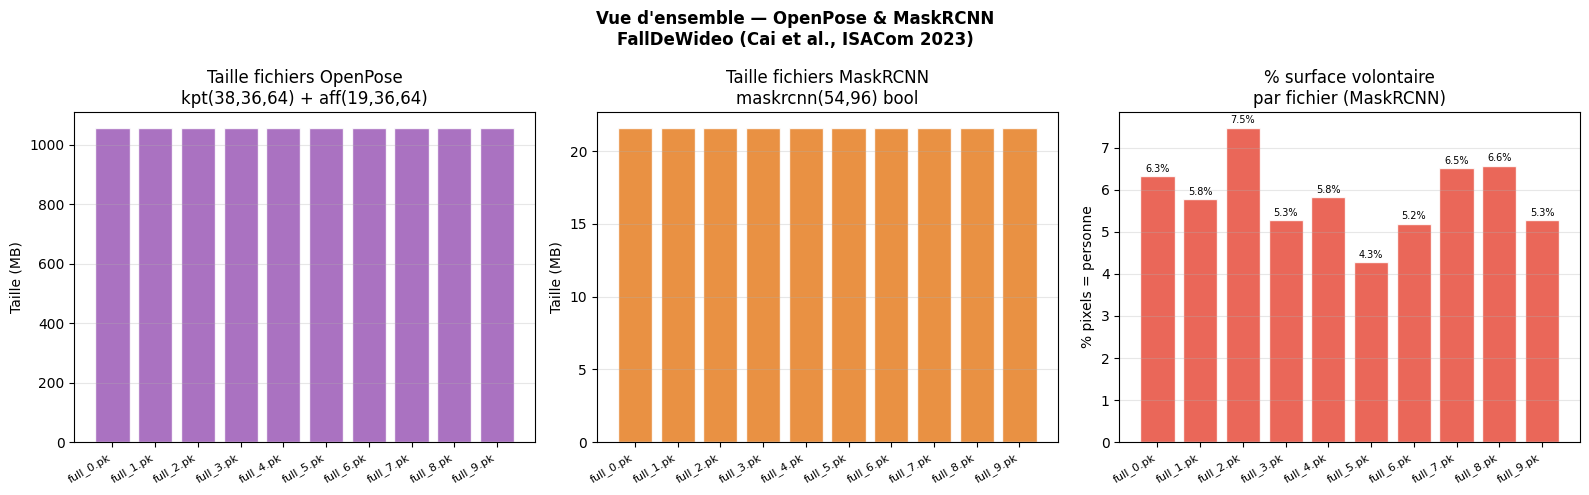


📊 OpenPose  : 10569 MB | 40,200 lignes
📊 MaskRCNN  : 216 MB | 40,200 lignes


In [18]:
# ============================================================
# CELLULE B3 — Vue d'ensemble 10 fichiers OpenPose + MaskRCNN
# kpt=(38,36,64) aff=(19,36,64) | maskrcnn=(54,96) bool
# ============================================================
import pickle, os
import numpy as np
import matplotlib.pyplot as plt
import gc

# ── OpenPose ─────────────────────────────────────────────────
print(f"{'Fichier':12s} | {'Taille':>7s} | {'Lignes':>6s} | "
      f"{'kpt shape':>12s} | {'aff shape':>12s} | Source")
print("─" * 75)

rows_op = []
for path in OPENPOSE_FILES:
    fname   = path.split('/')[-1]
    size_mb = os.path.getsize(path) / 1e6
    src     = "missing" if "missing" in path else "openpose"

    with open(path, "rb") as f:
        df = pickle.load(f)

    n    = len(df)
    kpt0 = df['kpt'].iloc[0]
    aff0 = df['aff'].iloc[0]
    rows_op.append((fname, size_mb, n,
                    str(kpt0.shape), str(aff0.shape), src))
    icon = "📦" if src == "missing" else "📄"
    print(f"{icon} {fname:12s} | {size_mb:6.0f}MB | {n:5d} lg | "
          f"{str(kpt0.shape):>12s} | {str(aff0.shape):>12s} | {src}")
    del df; gc.collect()

# ── MaskRCNN ─────────────────────────────────────────────────
print(f"\n{'Fichier':12s} | {'Taille':>7s} | {'Lignes':>6s} | "
      f"{'mask shape':>12s} | {'% personne':>11s}")
print("─" * 65)

rows_mr = []
for path in MASKRCNN_FILES:
    fname   = path.split('/')[-1]
    size_mb = os.path.getsize(path) / 1e6

    with open(path, "rb") as f:
        df = pickle.load(f)

    n       = len(df)
    mask0   = df['maskrcnn'].iloc[0]
    idx_s   = np.random.choice(n, min(10, n), replace=False)
    pct_avg = np.mean([df['maskrcnn'].iloc[i].mean()*100
                       for i in idx_s])
    rows_mr.append((fname, size_mb, n,
                    str(mask0.shape), pct_avg))
    print(f"📄 {fname:12s} | {size_mb:6.0f}MB | {n:5d} lg | "
          f"{str(mask0.shape):>12s} | {pct_avg:10.2f}%")
    del df; gc.collect()

# ── Graphiques ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Vue d'ensemble — OpenPose & MaskRCNN\n"
             "FallDeWideo (Cai et al., ISACom 2023)",
             fontsize=12, fontweight='bold')

x = np.arange(10)

ax = axes[0]
ax.bar(x, [r[1] for r in rows_op],
       color='#9b59b6', alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels([r[0] for r in rows_op],
                   rotation=30, ha='right', fontsize=8)
ax.set_ylabel("Taille (MB)")
ax.set_title("Taille fichiers OpenPose\n"
             "kpt(38,36,64) + aff(19,36,64)")
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
ax.bar(x, [r[1] for r in rows_mr],
       color='#e67e22', alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels([r[0] for r in rows_mr],
                   rotation=30, ha='right', fontsize=8)
ax.set_ylabel("Taille (MB)")
ax.set_title("Taille fichiers MaskRCNN\n"
             "maskrcnn(54,96) bool")
ax.grid(axis='y', alpha=0.3)

ax = axes[2]
ax.bar(x, [r[4] for r in rows_mr],
       color='#e74c3c', alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels([r[0] for r in rows_mr],
                   rotation=30, ha='right', fontsize=8)
ax.set_ylabel("% pixels = personne")
ax.set_title("% surface volontaire\npar fichier (MaskRCNN)")
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate([r[4] for r in rows_mr]):
    ax.text(i, v+0.1, f"{v:.1f}%", ha='center', fontsize=7)

plt.tight_layout()
plt.savefig("/kaggle/working/rgb_overview.png",
            dpi=120, bbox_inches='tight')
plt.show()

print(f"\n📊 OpenPose  : {sum(r[1] for r in rows_op):.0f} MB | "
      f"{sum(r[2] for r in rows_op):,} lignes")
print(f"📊 MaskRCNN  : {sum(r[1] for r in rows_mr):.0f} MB | "
      f"{sum(r[2] for r in rows_mr):,} lignes")

aff (JHM) shape : (19, 36, 64)
kpt (PAF) shape : (38, 36, 64)


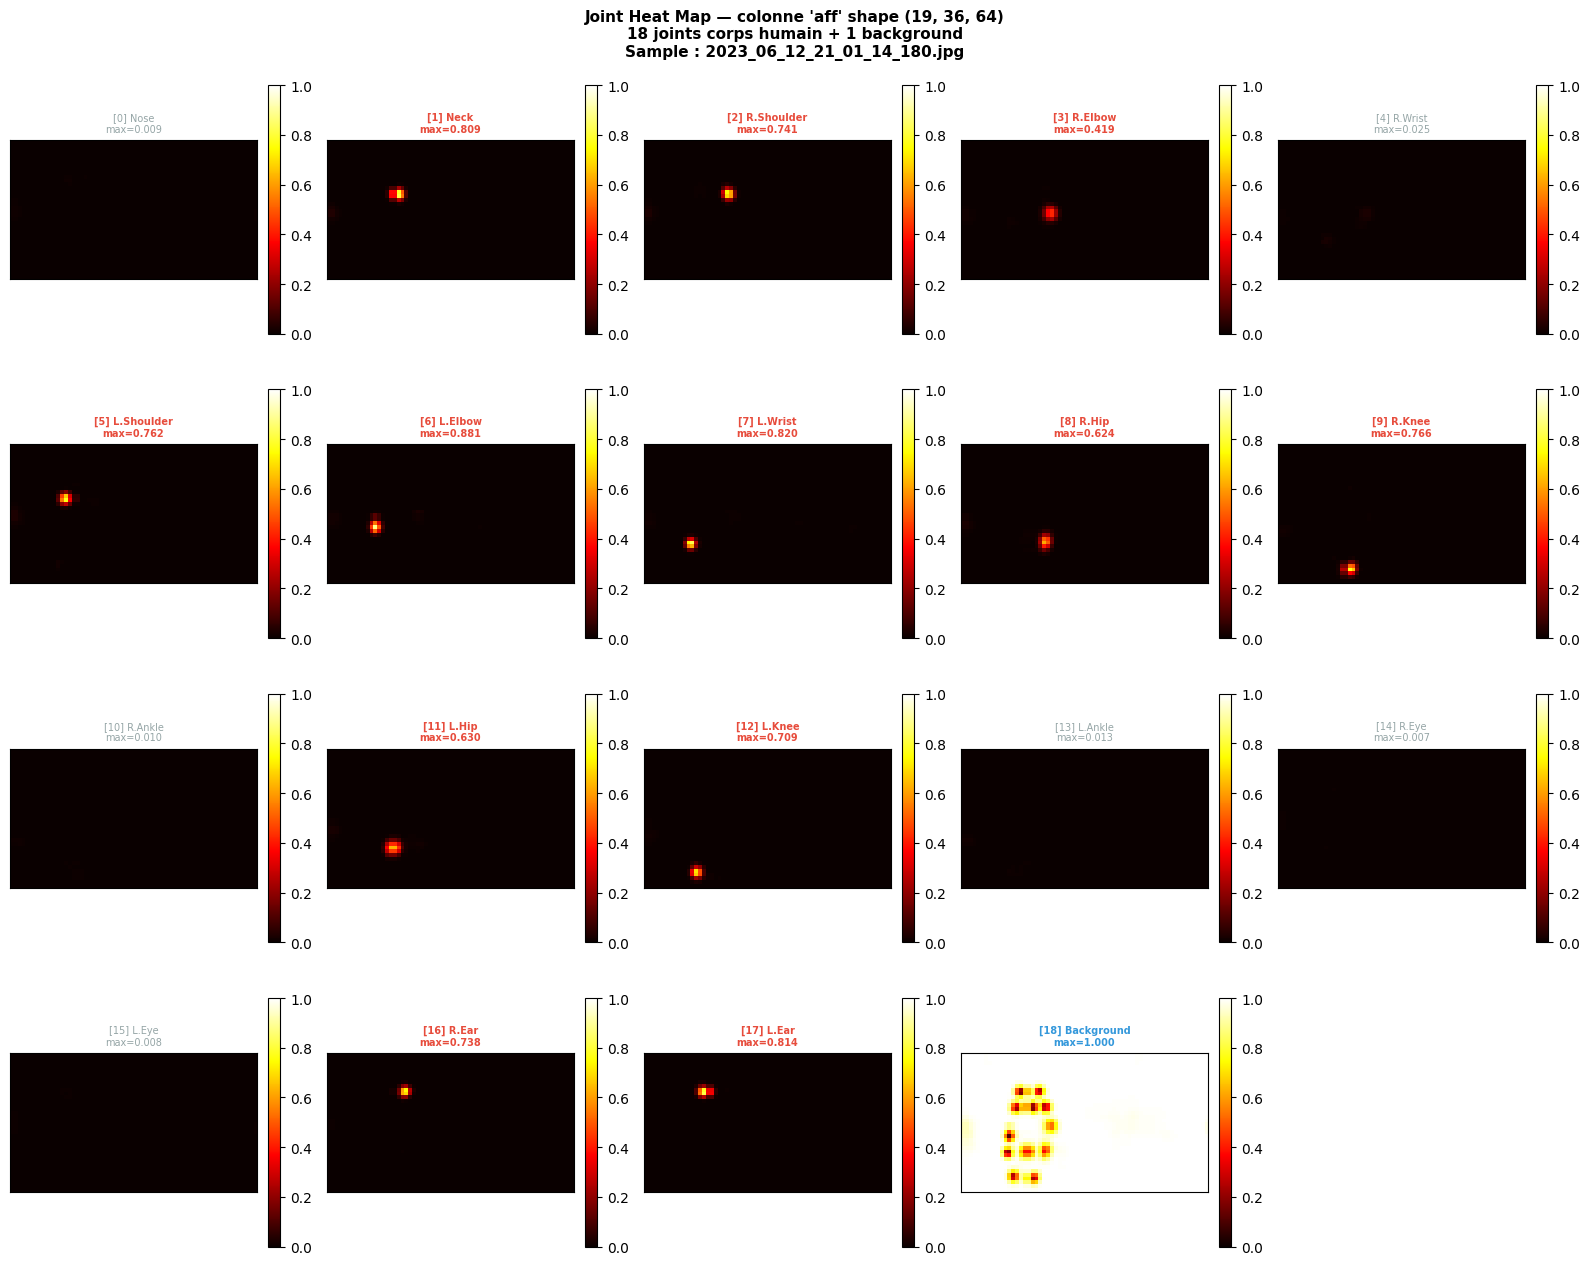


📊 Joints détectés (max > 0.05) :
  [ 0] Nose           : ❌  max=0.0086
  [ 1] Neck           : ✅  max=0.8091
  [ 2] R.Shoulder     : ✅  max=0.7407
  [ 3] R.Elbow        : ✅  max=0.4194
  [ 4] R.Wrist        : ❌  max=0.0249
  [ 5] L.Shoulder     : ✅  max=0.7622
  [ 6] L.Elbow        : ✅  max=0.8813
  [ 7] L.Wrist        : ✅  max=0.8198
  [ 8] R.Hip          : ✅  max=0.6235
  [ 9] R.Knee         : ✅  max=0.7656
  [10] R.Ankle        : ❌  max=0.0100
  [11] L.Hip          : ✅  max=0.6299
  [12] L.Knee         : ✅  max=0.7090
  [13] L.Ankle        : ❌  max=0.0135
  [14] R.Eye          : ❌  max=0.0071
  [15] L.Eye          : ❌  max=0.0078
  [16] R.Ear          : ✅  max=0.7383
  [17] L.Ear          : ✅  max=0.8145


In [19]:
# ============================================================
# CELLULE B4 — Visualisation JHM (colonne 'aff')
# aff shape : (19, 36, 64) float16
# 18 joints du corps + 1 background
# ============================================================
import pickle
import numpy as np
import matplotlib.pyplot as plt
import gc

JOINT_NAMES = [
    'Nose','Neck',
    'R.Shoulder','R.Elbow','R.Wrist',
    'L.Shoulder','L.Elbow','L.Wrist',
    'R.Hip','R.Knee','R.Ankle',
    'L.Hip','L.Knee','L.Ankle',
    'R.Eye','L.Eye','R.Ear','L.Ear',
    'Background'
]

with open(OPENPOSE_FILES[1], "rb") as f:
    df_op = pickle.load(f)

aff = df_op['aff'].iloc[10].astype(np.float32)  # (19, 36, 64)
kpt = df_op['kpt'].iloc[10].astype(np.float32)  # (38, 36, 64)
pic = df_op['pic'].iloc[10]
del df_op; gc.collect()

print(f"aff (JHM) shape : {aff.shape}")
print(f"kpt (PAF) shape : {kpt.shape}")

fig, axes = plt.subplots(4, 5, figsize=(16, 13))
fig.suptitle("Joint Heat Map — colonne 'aff' shape (19, 36, 64)\n"
             "18 joints corps humain + 1 background\n"
             f"Sample : {pic.split('/')[-1]}",
             fontsize=11, fontweight='bold')

for idx in range(19):
    ax = axes.flat[idx]
    channel = aff[idx]
    im = ax.imshow(channel, cmap='hot',
                   origin='upper', interpolation='nearest',
                   vmin=0, vmax=aff.max())
    detected = channel.max() > 0.05
    color    = '#e74c3c' if idx < 18 and detected else \
               '#3498db' if idx == 18 else '#95a5a6'
    ax.set_title(f"[{idx}] {JOINT_NAMES[idx]}\n"
                 f"max={channel.max():.3f}",
                 fontsize=7, color=color,
                 fontweight='bold' if detected else 'normal')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks([]); ax.set_yticks([])

# Dernier axe libre
axes.flat[19].axis('off')

plt.tight_layout()
plt.savefig("/kaggle/working/openpose_aff_jhm.png",
            dpi=120, bbox_inches='tight')
plt.show()

print(f"\n📊 Joints détectés (max > 0.05) :")
for i, name in enumerate(JOINT_NAMES[:18]):
    det = aff[i].max() > 0.05
    print(f"  [{i:2d}] {name:15s}: "
          f"{'✅' if det else '❌'}  max={aff[i].max():.4f}")

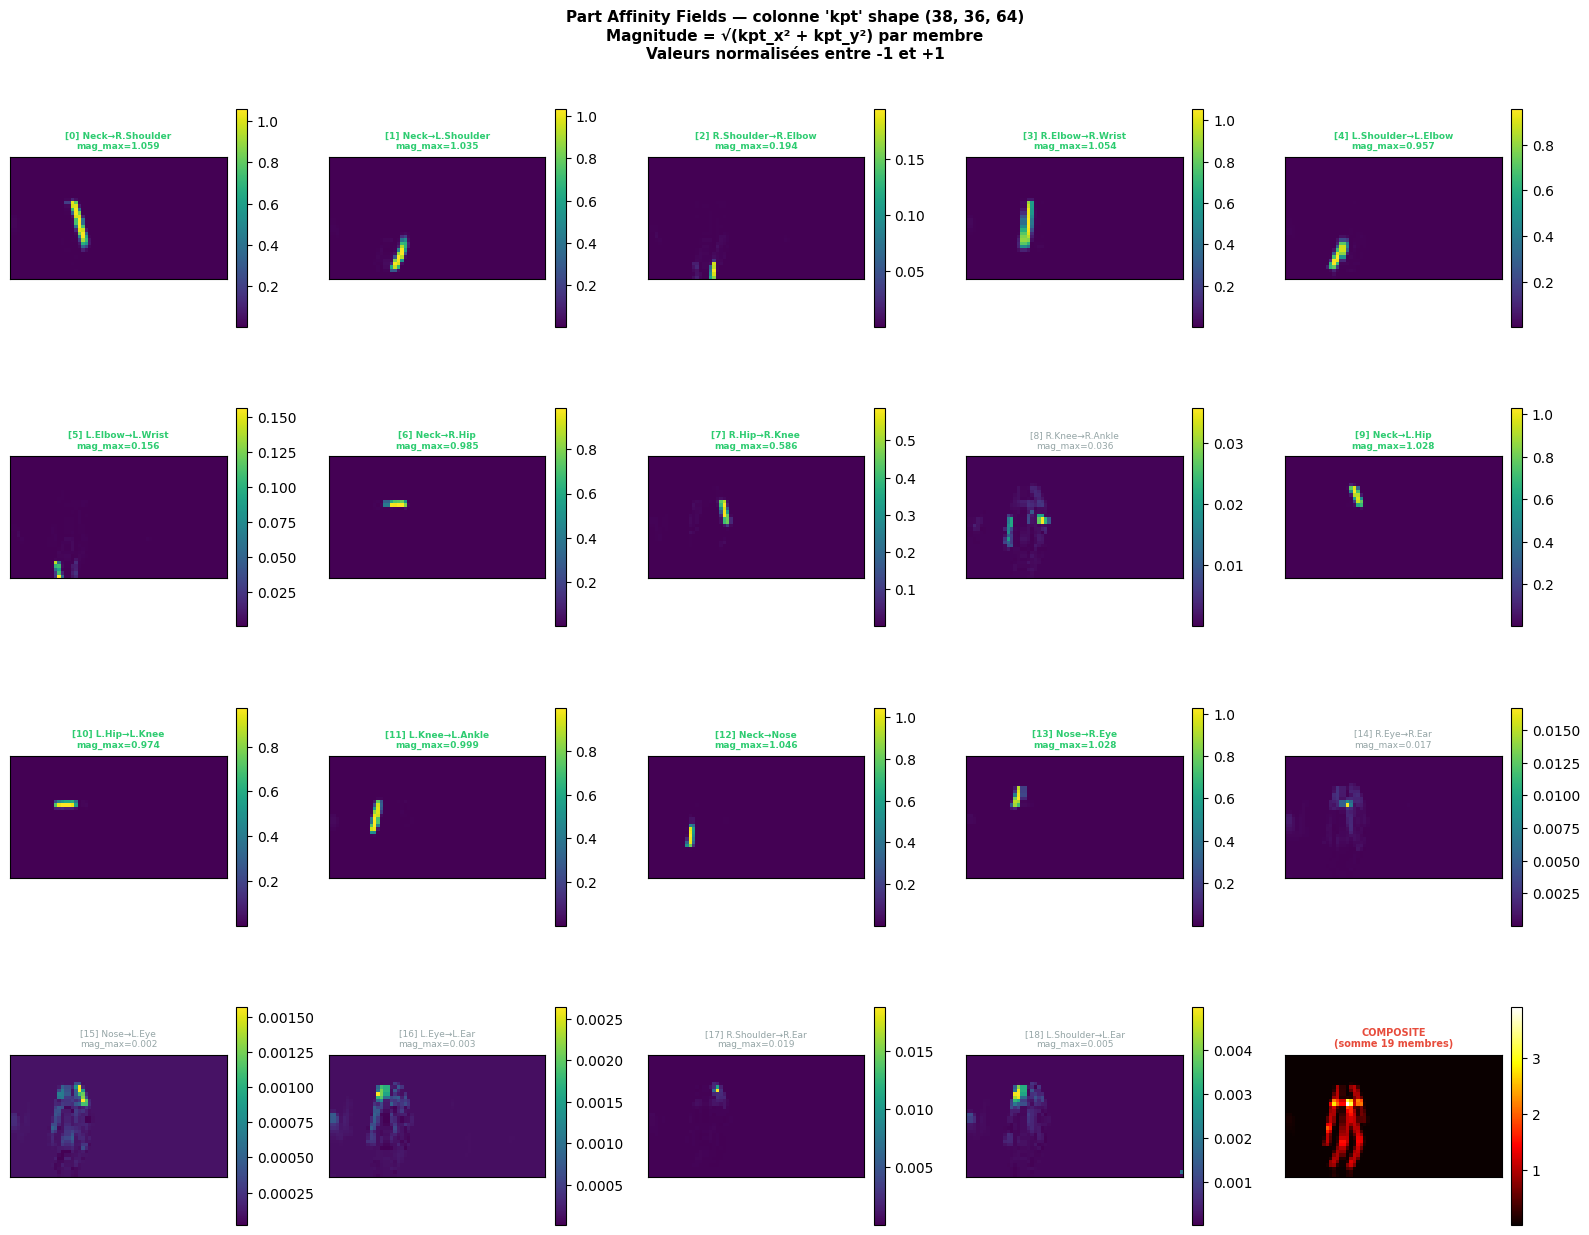


📊 Membres actifs (magnitude max > 0.05) :
  [ 0] Neck→R.Shoulder       : ✅  max=1.0591
  [ 1] Neck→L.Shoulder       : ✅  max=1.0347
  [ 2] R.Shoulder→R.Elbow    : ✅  max=0.1944
  [ 3] R.Elbow→R.Wrist       : ✅  max=1.0538
  [ 4] L.Shoulder→L.Elbow    : ✅  max=0.9567
  [ 5] L.Elbow→L.Wrist       : ✅  max=0.1561
  [ 6] Neck→R.Hip            : ✅  max=0.9846
  [ 7] R.Hip→R.Knee          : ✅  max=0.5862
  [ 8] R.Knee→R.Ankle        : ❌  max=0.0356
  [ 9] Neck→L.Hip            : ✅  max=1.0280
  [10] L.Hip→L.Knee          : ✅  max=0.9740
  [11] L.Knee→L.Ankle        : ✅  max=0.9991
  [12] Neck→Nose             : ✅  max=1.0456
  [13] Nose→R.Eye            : ✅  max=1.0284
  [14] R.Eye→R.Ear           : ❌  max=0.0167
  [15] Nose→L.Eye            : ❌  max=0.0016
  [16] L.Eye→L.Ear           : ❌  max=0.0026
  [17] R.Shoulder→R.Ear      : ❌  max=0.0188
  [18] L.Shoulder→L.Ear      : ❌  max=0.0050


In [20]:
# ============================================================
# CELLULE B5 — Visualisation PAF (colonne 'kpt')
# kpt shape : (38, 36, 64) float16
# 19 membres × 2 directions (x, y)
# Valeurs entre -1 et +1 (direction normalisée)
# ============================================================
import pickle
import numpy as np
import matplotlib.pyplot as plt
import gc

LIMB_NAMES = [
    'Neck→R.Shoulder', 'Neck→L.Shoulder',
    'R.Shoulder→R.Elbow', 'R.Elbow→R.Wrist',
    'L.Shoulder→L.Elbow', 'L.Elbow→L.Wrist',
    'Neck→R.Hip', 'R.Hip→R.Knee', 'R.Knee→R.Ankle',
    'Neck→L.Hip', 'L.Hip→L.Knee', 'L.Knee→L.Ankle',
    'Neck→Nose',
    'Nose→R.Eye', 'R.Eye→R.Ear',
    'Nose→L.Eye', 'L.Eye→L.Ear',
    'R.Shoulder→R.Ear', 'L.Shoulder→L.Ear'
]

with open(OPENPOSE_FILES[1], "rb") as f:
    df_op = pickle.load(f)

kpt = df_op['kpt'].iloc[10].astype(np.float32)
aff = df_op['aff'].iloc[10].astype(np.float32)
del df_op; gc.collect()

fig, axes = plt.subplots(4, 5, figsize=(16, 13))
fig.suptitle("Part Affinity Fields — colonne 'kpt' shape (38, 36, 64)\n"
             "Magnitude = √(kpt_x² + kpt_y²) par membre\n"
             "Valeurs normalisées entre -1 et +1",
             fontsize=11, fontweight='bold')

for idx in range(19):
    ax = axes.flat[idx]
    paf_x     = kpt[idx * 2]
    paf_y     = kpt[idx * 2 + 1]
    magnitude = np.sqrt(paf_x**2 + paf_y**2)
    detected  = magnitude.max() > 0.05
    im = ax.imshow(magnitude, cmap='viridis',
                   origin='upper', interpolation='nearest')
    ax.set_title(f"[{idx}] {LIMB_NAMES[idx]}\n"
                 f"mag_max={magnitude.max():.3f}",
                 fontsize=6.5,
                 color='#2ecc71' if detected else '#95a5a6',
                 fontweight='bold' if detected else 'normal')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks([]); ax.set_yticks([])

# Composite tous membres
ax = axes.flat[19]
composite = np.zeros(kpt.shape[1:])
for i in range(19):
    composite += np.sqrt(kpt[i*2]**2 + kpt[i*2+1]**2)
im = ax.imshow(composite, cmap='hot',
               origin='upper', interpolation='nearest')
ax.set_title("COMPOSITE\n(somme 19 membres)",
             fontsize=7, color='#e74c3c', fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig("/kaggle/working/openpose_kpt_paf.png",
            dpi=120, bbox_inches='tight')
plt.show()

print(f"\n📊 Membres actifs (magnitude max > 0.05) :")
for i, name in enumerate(LIMB_NAMES):
    mag = np.sqrt(kpt[i*2]**2 + kpt[i*2+1]**2)
    print(f"  [{i:2d}] {name:22s}: "
          f"{'✅' if mag.max()>0.05 else '❌'}  "
          f"max={mag.max():.4f}")

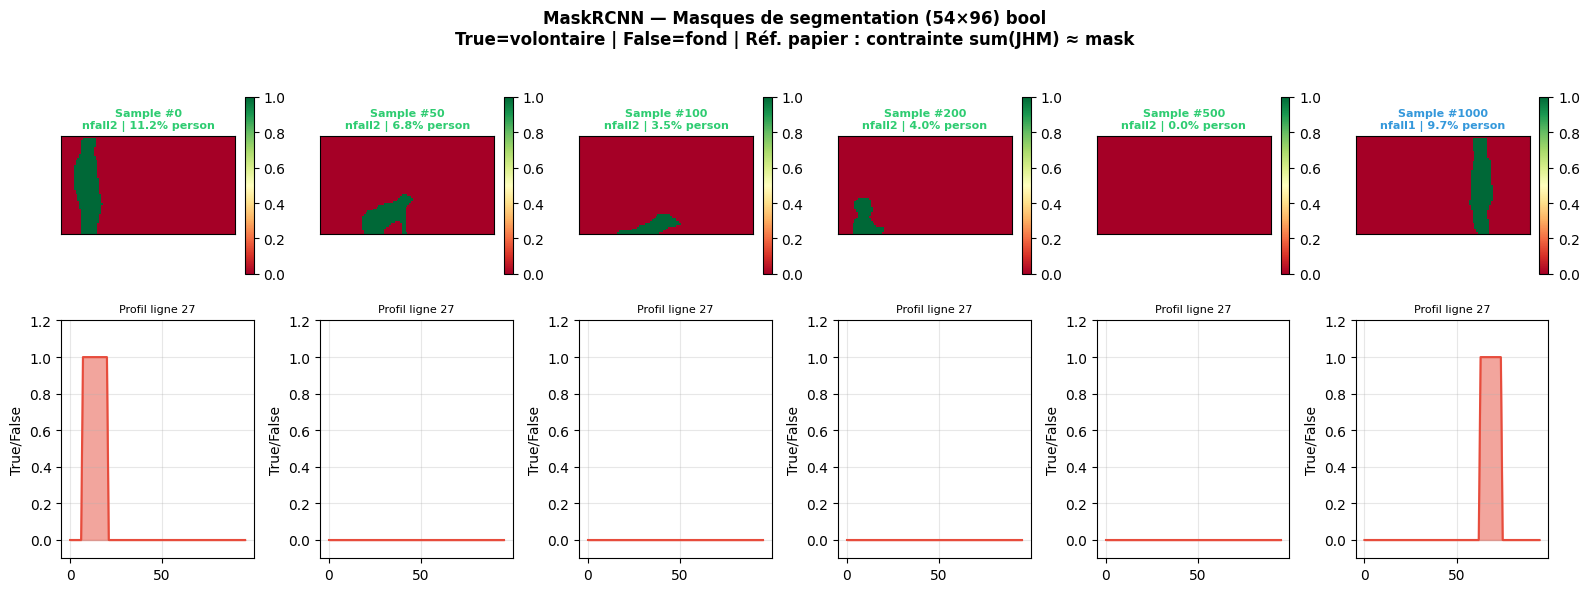

In [21]:
# ============================================================
# CELLULE B6 — Visualisation MaskRCNN
# maskrcnn shape : (54, 96) bool — directement 2D
# True = pixel appartient au volontaire
# ============================================================
import pickle
import numpy as np
import matplotlib.pyplot as plt
import gc

with open(MASKRCNN_FILES[0], "rb") as f:
    df_mr = pickle.load(f)

idx_list = [0, 50, 100, 200, 500, 1000]
samples  = [(df_mr['maskrcnn'].iloc[i],
             df_mr['pic'].iloc[i], i)
            for i in idx_list if i < len(df_mr)]
del df_mr; gc.collect()

fig, axes = plt.subplots(2, len(samples), figsize=(16, 6))
fig.suptitle("MaskRCNN — Masques de segmentation (54×96) bool\n"
             "True=volontaire | False=fond | "
             "Réf. papier : contrainte sum(JHM) ≈ mask",
             fontsize=12, fontweight='bold')

for col, (mask, pic, idx) in enumerate(samples):
    # Masque binaire
    ax = axes[0, col]
    im = ax.imshow(mask.astype(np.float32),
                   cmap='RdYlGn', origin='upper',
                   vmin=0, vmax=1, interpolation='nearest')
    pct = mask.mean() * 100
    move = pic.split('/')[7].split('_')[1] \
           if len(pic.split('/')) > 7 else '?'
    ax.set_title(f"Sample #{idx}\n"
                 f"{move} | {pct:.1f}% person",
                 fontsize=8, fontweight='bold',
                 color='#e74c3c' if move=='fall' else
                       '#3498db' if move=='nfall1' else '#2ecc71')
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_xticks([]); ax.set_yticks([])

    # Profil horizontal au milieu
    ax = axes[1, col]
    mid = mask.shape[0] // 2
    ax.fill_between(range(mask.shape[1]),
                    mask[mid].astype(int),
                    alpha=0.5, color='#e74c3c')
    ax.plot(mask[mid].astype(int),
            color='#e74c3c', linewidth=1.5)
    ax.set_title(f"Profil ligne {mid}", fontsize=8)
    ax.set_ylim(-0.1, 1.2)
    ax.set_ylabel("True/False"); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/maskrcnn_samples.png",
            dpi=120, bbox_inches='tight')
plt.show()

## Note — Disponibilité des images RGB brutes

Le dataset **FallDeWideo** (Cai et al., ISACom@MobiCom 2023) ne distribue **pas** les images RGB brutes (frames JPG 1920×1080) capturées lors de la collecte. Le partage du dataset (SharePoint, auteurs) et notre dépôt Kaggle ne contiennent que les trois modalités dérivées suivantes :

- **`csi/`** — signaux CSI Wi-Fi bruts (Intel 5300, 1000 Hz)
- **`openpose/`** — heatmaps de keypoints (JHM, 19×36×64) et Part Affinity Fields (PAF, 38×36×64) extraits via OpenPose
- **`maskrcnn/`** — masques de segmentation binaire de la personne (~54×96) extraits via Mask R-CNN

Les images brutes ne sont donc accessibles à aucune étape de notre pipeline, y compris en amont (côté auteurs). Cette absence est cohérente avec une pratique de **protection de la vie privée des sujets** : contrairement aux images RGB, les squelettes et masques de segmentation ne permettent pas d'identifier visuellement une personne, tout en conservant l'information spatiale nécessaire à la détection de chute.

**Conséquence pour ce travail** : la branche vision de CausalFuseHAR est entraînée directement sur les features dérivées (JHM/PAF + masque), sans jamais nécessiter l'image RGB originale — ce qui est cohérent avec l'architecture prévue et ne constitue pas une limitation pour l'entraînement du modèle.

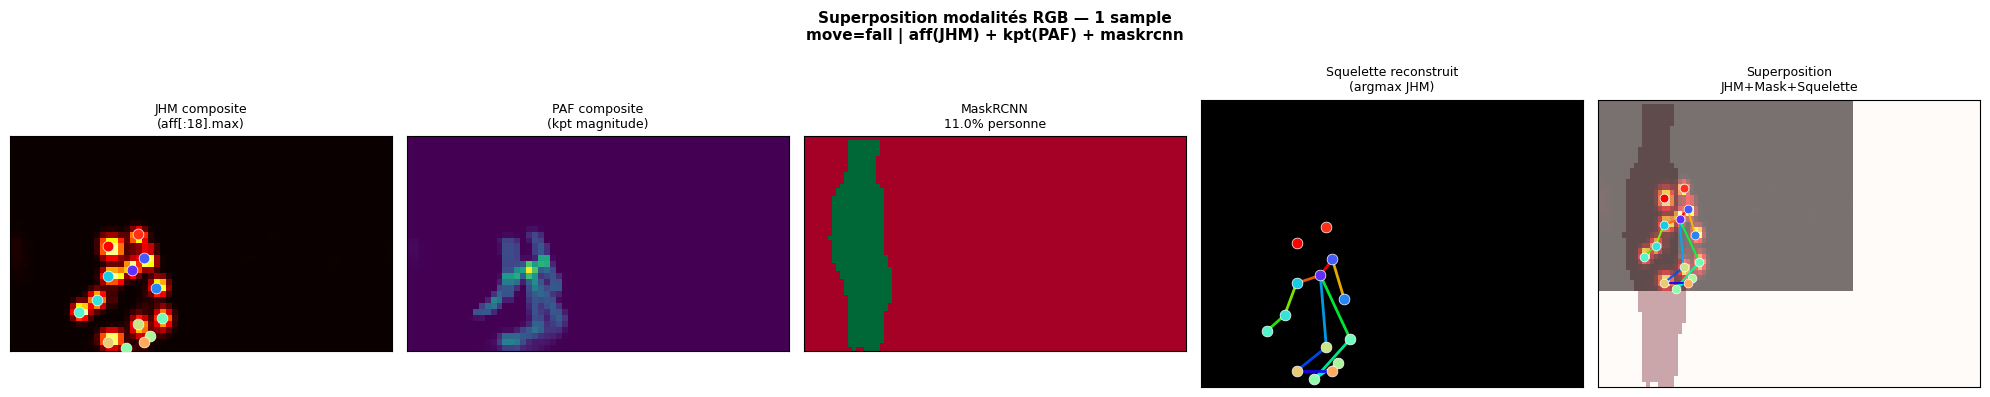


📊 Joints détectés : 14/18
   Masque couverture : 11.00%
   JHM max global    : 0.8301
   PAF mag max       : 3.9910


In [22]:
# ============================================================
# CELLULE B7 — Superposition aff + kpt + maskrcnn
# Vue complète d'un sample : les 3 modalités alignées
# ============================================================
import pickle
import numpy as np
import matplotlib.pyplot as plt
import gc

JOINT_NAMES_SHORT = [
    'Nose','Neck','RSh','REl','RWr',
    'LSh','LEl','LWr','RHip','RKn',
    'RAn','LHip','LKn','LAn',
    'REye','LEye','REar','LEar','Bg'
]
SKELETON = [
    (1,2),(1,5),(2,3),(3,4),(5,6),(6,7),
    (1,8),(8,9),(9,10),(1,11),(11,12),(12,13),
    (1,0),(0,14),(14,16),(0,15),(15,17),
]
JCOLORS = plt.cm.rainbow(np.linspace(0, 1, 18))
SCOLORS = plt.cm.hsv(np.linspace(0, 1, len(SKELETON)))

with open(OPENPOSE_FILES[1], "rb") as f:
    df_op = pickle.load(f)
aff = df_op['aff'].iloc[15].astype(np.float32)
kpt = df_op['kpt'].iloc[15].astype(np.float32)
pic = df_op['pic'].iloc[15]
del df_op; gc.collect()

with open(MASKRCNN_FILES[0], "rb") as f:
    df_mr = pickle.load(f)
mask = df_mr['maskrcnn'].iloc[15].astype(np.float32)
del df_mr; gc.collect()

# Extraire positions joints depuis aff (argmax)
H, W = aff.shape[1], aff.shape[2]
joints = []
for i in range(18):
    ch = aff[i]
    if ch.max() > 0.05:
        fi    = ch.argmax()
        y, x  = fi // W, fi % W
        joints.append((x, y, float(ch.max())))
    else:
        joints.append(None)

# Composite JHM et PAF
jhm_comp = aff[:18].max(axis=0)
paf_comp = np.zeros((H, W))
for i in range(19):
    paf_comp += np.sqrt(kpt[i*2]**2 + kpt[i*2+1]**2)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle("Superposition modalités RGB — 1 sample\n"
             f"move={pic.split('/')[7].split('_')[1] if len(pic.split('/'))>7 else '?'}"
             f" | aff(JHM) + kpt(PAF) + maskrcnn",
             fontsize=11, fontweight='bold')

# 1. JHM composite
ax = axes[0]
ax.imshow(jhm_comp, cmap='hot', origin='upper')
for i, pos in enumerate(joints):
    if pos:
        ax.scatter(pos[0], pos[1], c=[JCOLORS[i]],
                   s=60, zorder=5, edgecolors='white', lw=0.5)
ax.set_title("JHM composite\n(aff[:18].max)", fontsize=9)
ax.set_xticks([]); ax.set_yticks([])

# 2. PAF composite
ax = axes[1]
ax.imshow(paf_comp, cmap='viridis', origin='upper')
ax.set_title("PAF composite\n(kpt magnitude)", fontsize=9)
ax.set_xticks([]); ax.set_yticks([])

# 3. Masque
ax = axes[2]
ax.imshow(mask, cmap='RdYlGn', origin='upper', vmin=0, vmax=1)
ax.set_title(f"MaskRCNN\n{mask.mean()*100:.1f}% personne",
             fontsize=9)
ax.set_xticks([]); ax.set_yticks([])

# 4. Squelette
ax = axes[3]
ax.set_facecolor('black')
ax.set_xlim(0, W); ax.set_ylim(H, 0)
for i, (j1, j2) in enumerate(SKELETON):
    if joints[j1] and joints[j2]:
        ax.plot([joints[j1][0], joints[j2][0]],
                [joints[j1][1], joints[j2][1]],
                color=SCOLORS[i], lw=2, alpha=0.9)
for i, pos in enumerate(joints):
    if pos:
        ax.scatter(pos[0], pos[1], c=[JCOLORS[i]],
                   s=60, zorder=5, edgecolors='white', lw=0.5)
ax.set_title("Squelette reconstruit\n(argmax JHM)",
             fontsize=9)
ax.set_xticks([]); ax.set_yticks([])

# 5. Superposition complète
ax = axes[4]
ax.imshow(mask, cmap='Reds', alpha=0.35,
          origin='upper', aspect='auto')
ax.imshow(jhm_comp, cmap='hot', alpha=0.55,
          origin='upper', aspect='auto')
for i, (j1, j2) in enumerate(SKELETON):
    if joints[j1] and joints[j2]:
        ax.plot([joints[j1][0], joints[j2][0]],
                [joints[j1][1], joints[j2][1]],
                color=SCOLORS[i], lw=1.5, alpha=0.9)
for i, pos in enumerate(joints):
    if pos:
        ax.scatter(pos[0], pos[1], c=[JCOLORS[i]],
                   s=40, zorder=5, edgecolors='white', lw=0.5)
ax.set_title("Superposition\nJHM+Mask+Squelette",
             fontsize=9)
ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig("/kaggle/working/rgb_superposition.png",
            dpi=120, bbox_inches='tight')
plt.show()

n_det = sum(1 for p in joints if p is not None)
print(f"\n📊 Joints détectés : {n_det}/18")
print(f"   Masque couverture : {mask.mean()*100:.2f}%")
print(f"   JHM max global    : {jhm_comp.max():.4f}")
print(f"   PAF mag max       : {paf_comp.max():.4f}")

Recherche samples fall/nfall1/nfall2...


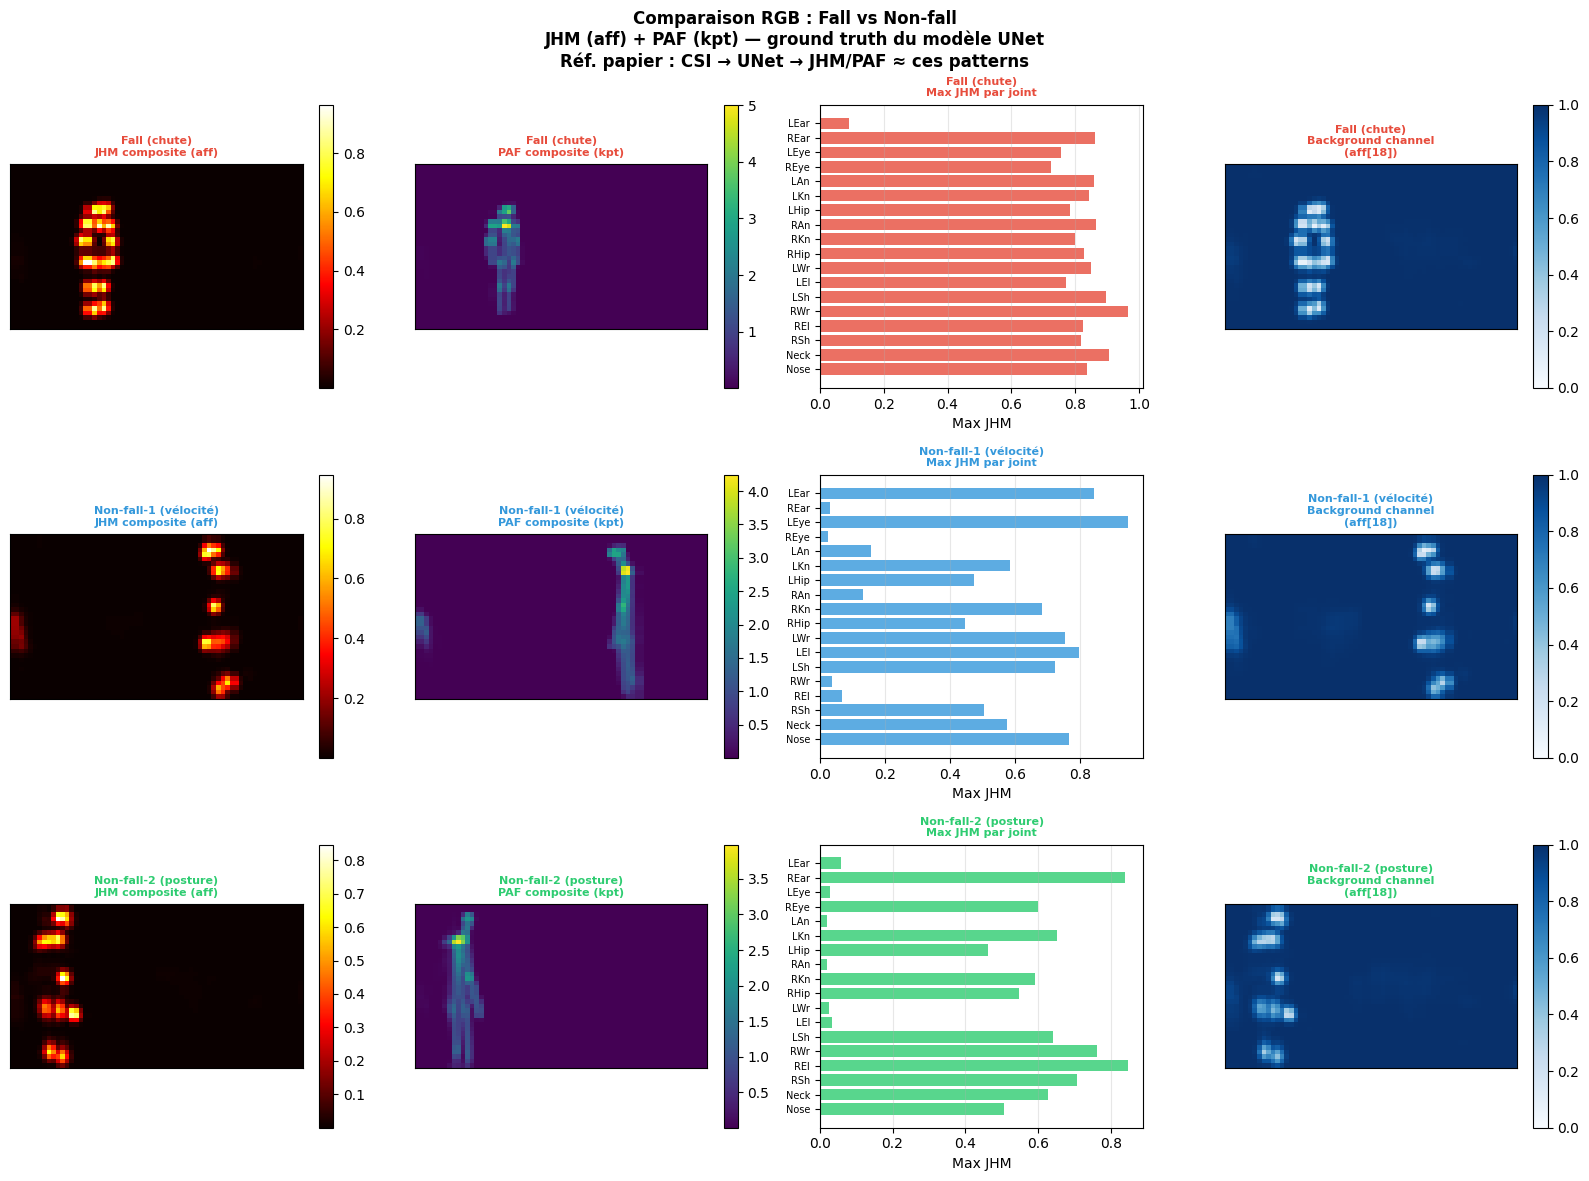


📊 Résumé :
  fall    : 18/18 joints | JHM max=0.965 | PAF max=5.011
  nfall1  : 15/18 joints | JHM max=0.947 | PAF max=4.247
  nfall2  : 13/18 joints | JHM max=0.847 | PAF max=3.981


In [23]:
# ============================================================
# CELLULE B8 — Comparaison Fall vs Non-fall
# JHM (aff) + PAF (kpt) côte à côte pour les 3 activités
# ============================================================
import pickle
import numpy as np
import matplotlib.pyplot as plt
import gc

def get_move(pic_path):
    try:
        return pic_path.split('/')[7].split('_')[1]
    except:
        return '?'

print("Recherche samples fall/nfall1/nfall2...")
found = {'fall': None, 'nfall1': None, 'nfall2': None}

for path in OPENPOSE_FILES[:3]:
    with open(path, "rb") as f:
        df = pickle.load(f)
    for idx in range(len(df)):
        move = get_move(df['pic'].iloc[idx])
        if move in found and found[move] is None:
            found[move] = {
                'aff': df['aff'].iloc[idx].astype(np.float32),
                'kpt': df['kpt'].iloc[idx].astype(np.float32),
                'pic': df['pic'].iloc[idx],
            }
        if all(v is not None for v in found.values()):
            break
    del df; gc.collect()
    if all(v is not None for v in found.values()):
        break

COLORS = {'fall':'#e74c3c','nfall1':'#3498db','nfall2':'#2ecc71'}
LABELS = {'fall':'Fall (chute)',
          'nfall1':'Non-fall-1 (vélocité)',
          'nfall2':'Non-fall-2 (posture)'}

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle("Comparaison RGB : Fall vs Non-fall\n"
             "JHM (aff) + PAF (kpt) — ground truth du modèle UNet\n"
             "Réf. papier : CSI → UNet → JHM/PAF ≈ ces patterns",
             fontsize=12, fontweight='bold')

for row, (move, data) in enumerate(found.items()):
    color = COLORS[move]
    label = LABELS[move]

    if data is None:
        for col in range(4):
            axes[row, col].text(0.5, 0.5, 'Non trouvé',
                ha='center', transform=axes[row,col].transAxes)
            axes[row, col].axis('off')
        continue

    aff = data['aff']
    kpt = data['kpt']

    # JHM composite
    ax = axes[row, 0]
    jhm_c = aff[:18].max(axis=0)
    im = ax.imshow(jhm_c, cmap='hot', origin='upper')
    ax.set_title(f"{label}\nJHM composite (aff)",
                 fontsize=8, color=color, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_xticks([]); ax.set_yticks([])

    # PAF composite
    ax = axes[row, 1]
    paf_c = np.zeros(kpt.shape[1:])
    for i in range(19):
        paf_c += np.sqrt(kpt[i*2]**2 + kpt[i*2+1]**2)
    im = ax.imshow(paf_c, cmap='viridis', origin='upper')
    ax.set_title(f"{label}\nPAF composite (kpt)",
                 fontsize=8, color=color, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_xticks([]); ax.set_yticks([])

    # Profil JHM par joint
    ax = axes[row, 2]
    joint_maxs = [float(aff[i].max()) for i in range(18)]
    ax.barh(range(18), joint_maxs, color=color, alpha=0.8)
    ax.set_yticks(range(18))
    ax.set_yticklabels([
        'Nose','Neck','RSh','REl','RWr',
        'LSh','LEl','LWr','RHip','RKn',
        'RAn','LHip','LKn','LAn',
        'REye','LEye','REar','LEar'], fontsize=7)
    ax.set_xlabel("Max JHM")
    ax.set_title(f"{label}\nMax JHM par joint",
                 fontsize=8, color=color, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

    # Background channel
    ax = axes[row, 3]
    im = ax.imshow(aff[18], cmap='Blues',
                   origin='upper', vmin=0, vmax=1)
    ax.set_title(f"{label}\nBackground channel\n(aff[18])",
                 fontsize=8, color=color, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig("/kaggle/working/rgb_fall_vs_nonfail.png",
            dpi=120, bbox_inches='tight')
plt.show()

print("\n📊 Résumé :")
for move, data in found.items():
    if data:
        jhm_c = data['aff'][:18].max(axis=0)
        paf_c = sum(np.sqrt(data['kpt'][i*2]**2 +
                            data['kpt'][i*2+1]**2)
                    for i in range(19))
        n_det = sum(1 for i in range(18)
                    if data['aff'][i].max() > 0.05)
        print(f"  {move:8s}: {n_det}/18 joints | "
              f"JHM max={jhm_c.max():.3f} | "
              f"PAF max={paf_c.max():.3f}")

## ✅ Synthèse — Modalités RGB (Structure Réelle)

### Structure réelle vs README officiel

| README officiel | Réalité dans tes fichiers |
|----------------|--------------------------|
| `jhm` (19, w, h) JHM | `aff` **(19, 36, 64)** float16 |
| `paf` (38, w, h) PAF | `kpt` **(38, 36, 64)** float16 |
| `mask` (1, w, h) | `maskrcnn` **(54, 96)** bool 2D |

### Interprétation des shapes

```
aff (JHM) : (19, 36, 64)
             │   │   └── largeur (w=64)
             │   └─────── hauteur (h=36)
             └─────────── 18 joints + 1 background

kpt (PAF) : (38, 36, 64)
             │   │   └── largeur (w=64)
             │   └─────── hauteur (h=36)
             └─────────── 19 membres × 2 directions (x, y)

maskrcnn  : (54, 96)    ← directement 2D, pas de dim channel
             │   └──── largeur (w=96)
             └────────── hauteur (h=54)
             valeurs : True/False (bool)
```

### Rôle dans le pipeline papier (Fig. 5)
```
CSI tensor (54×30×50)
    → UNet 1 → kpt_prédit (PAF) ≈ kpt ground truth
    → UNet 2 → aff_prédit (JHM) ≈ aff ground truth
    Contrainte : sum(aff_prédit, axis=0) ≈ maskrcnn

Loss = λ_SM · L(maskrcnn) + λ_JHM · L(aff) + λ_PAF · L(kpt)
```

### Ce qu'on a visualisé
- **aff** (JHM) : 19 canaux → localisation des 18 joints
- **kpt** (PAF) : magnitude √(x²+y²) → connexions entre joints
- **maskrcnn** : zone binaire du volontaire
- **Superposition** : alignement aff + kpt + mask sur même frame
- **Fall vs Non-fall** : patterns distincts → discriminatifs pour le modèle

# 🔗 Partie 2 — Prétraitement pour Fusion CSI + RGB

Contrairement au schéma du papier FallDeWideo original (RGB = supervision auxiliaire,
CSI = seule entrée), ce prétraitement prépare **les deux modalités comme entrées actives**
d'un modèle de fusion, conformément au sujet de stage RMFD (Robust Multi-modal Fall
Detector) : fusion caractéristiques + décisions, attention cross-modale, et **tolérance
aux défaillances capteur** (dropout, score de confiance).

**Étapes :**
1. Nettoyage + split cross-person (base commune aux deux modalités)
2. Tenseur CSI `(54, 30, 50)` — débruitage de phase + normalisation par instance
3. Tenseur RGB unifié — alignement spatial OpenPose/MaskRCNN sur une grille commune
4. **Jointure CSI ↔ RGB sur `pic`** — construction de paires multimodales synchronisées
5. **Simulation de pannes capteur** — dropout modality-level pour entraîner la robustesse
6. Pipeline batché complet, sauvegarde `.npz` prêts pour le DataLoader de fusion
7. Squelette de `Dataset` PyTorch retournant `(csi, rgb, modality_mask, label)`

### 🧹 Cellule D1 — Nettoyage et split, commun aux deux modalités

Base commune : CSI et RGB doivent partager exactement le même split train/val/test
(mêmes sujets, mêmes `pic`) pour éviter toute fuite entre les deux flux d'entrée
du modèle de fusion.

In [24]:
# ============================================================
# CELLULE D1 — Nettoyage + split cross-person (base commune CSI+RGB)
# ============================================================
import numpy as np
import pandas as pd

n0 = len(metadf)
metadf_clean = metadf.drop_duplicates(subset=['pic'], keep='first').copy()

if 'outlier_df' in dir() and len(outlier_df) > 0:
    bad_keys = set(zip(outlier_df['file'], outlier_df['row_idx']))
    mask_bad = metadf_clean.apply(
        lambda r: (r['file_name'], r['row_idx']) in bad_keys, axis=1)
    metadf_clean = metadf_clean[~mask_bad].copy()

const_cols = [c for c in ['site', 'light', 'freq']
              if c in metadf_clean.columns and metadf_clean[c].nunique() <= 1]
metadf_clean.drop(columns=const_cols, inplace=True)

MOVE_ENCODE = {'fall': 0, 'nfall1': 1, 'nfall2': 2}
metadf_clean['label'] = metadf_clean['move'].map(MOVE_ENCODE)

# Split cross-person (sujets disjoints)
TEST_SUBJECT, VAL_SUBJECT = ['chz'], ['mfy']
metadf_clean['split'] = 'train'
metadf_clean.loc[metadf_clean['obj'].isin(VAL_SUBJECT),  'split'] = 'val'
metadf_clean.loc[metadf_clean['obj'].isin(TEST_SUBJECT), 'split'] = 'test'

metadf_clean.reset_index(drop=True, inplace=True)
metadf_clean.to_pickle('/kaggle/working/metadf_clean.pk')

print(f"✅ metadf_clean : {metadf_clean.shape}  (base commune CSI+RGB)")
print(metadf_clean.groupby('split')['move'].value_counts())

✅ metadf_clean : (39052, 14)  (base commune CSI+RGB)
split  move  
test   fall       2396
       nfall2     1771
       nfall1     1553
train  nfall1    11798
       nfall2    10317
       fall       7438
val    nfall2     1885
       nfall1     1095
       fall        799
Name: count, dtype: int64


### 📶 Cellule D2 — Fonctions CSI : Hampel vectorisé + tenseur (54,30,50)

**Correction critique par rapport à la version précédente :** le filtre de Hampel en
boucle Python pure faisait ~10,8 millions d'appels sur tout le dataset — c'est ce qui
bloquait le pipeline à 0%. On le remplace par une version vectorisée avec
`scipy.ndimage.median_filter`, qui traite tout le tableau `(50,30,3,3)` d'un coup au
lieu d'élément par élément. Le résultat est identique, la vitesse gagne plusieurs
ordres de grandeur.

In [25]:
# ============================================================
# CELLULE D2 — Fonctions CSI (branche 1 de la fusion) — Hampel vectorisé
# ============================================================
import numpy as np
from scipy.ndimage import median_filter

def hampel_filter_vectorized(phase_array, window_size=5, n_sigmas=3.0):
    """
    phase_array : (50, 30, 3, 3) — filtre appliqué le long de l'axe temporel
    (axe 0) uniquement, vectorisé sur toutes les autres dimensions.
    """
    k = 1.4826
    med = median_filter(phase_array, size=(window_size, 1, 1, 1), mode='reflect')
    mad = k * median_filter(np.abs(phase_array - med),
                             size=(window_size, 1, 1, 1), mode='reflect')
    outliers = np.abs(phase_array - med) > n_sigmas * mad
    return np.where(outliers, med, phase_array)

def denoise_phase(phase_array):
    return hampel_filter_vectorized(phase_array)

def build_csi_tensor(csi0, csi1, csi2):
    """
    csi0, csi1, csi2 : chacun (50, 30, 3, 3) complex128 — un receiver
    Retourne : tenseur (54, 30, 50)
      54 = 2 (amp+phase) x 3TX x 3RX x 3 receivers
    """
    channels = []
    for csi in (csi0, csi1, csi2):
        amp   = np.abs(csi)
        phase = denoise_phase(np.angle(csi))
        amp_r   = amp.transpose(1, 2, 3, 0).reshape(30, 9, 50).transpose(1, 0, 2)
        phase_r = phase.transpose(1, 2, 3, 0).reshape(30, 9, 50).transpose(1, 0, 2)
        channels += [amp_r, phase_r]
    return np.concatenate(channels, axis=0).astype(np.float32)  # (54,30,50)

def instance_norm_per_subcarrier(tensor, eps=1e-6):
    mean = tensor.mean(axis=2, keepdims=True)
    std  = tensor.std(axis=2, keepdims=True)
    return (tensor - mean) / (std + eps)

# ── Test rapide de vitesse ──────────────────────────────────
import pickle, gc, time
with open(CSI_FILES[0], "rb") as f:
    df_test = pickle.load(f)

t0 = time.time()
t = build_csi_tensor(df_test['csi0'].iloc[0],
                      df_test['csi1'].iloc[0],
                      df_test['csi2'].iloc[0])
t1 = time.time()

print(f"Shape tenseur CSI : {t.shape}  (attendu : (54, 30, 50))")
print(f"Temps pour 1 sample : {(t1-t0)*1000:.1f} ms")
print(f"Temps estimé pour 40 200 samples : {(t1-t0)*40200/60:.1f} min")

del df_test; gc.collect()

Shape tenseur CSI : (54, 30, 50)  (attendu : (54, 30, 50))
Temps pour 1 sample : 11.9 ms
Temps estimé pour 40 200 samples : 8.0 min


50081

### 🎯 Cellule D3 — Fonctions RGB : alignement spatial + stack en tenseur unique

On aligne `aff` (JHM, 19×36×64), `kpt` (PAF, 38×36×64) et `maskrcnn` (54×96 →
redimensionné en 36×64) sur la même grille, puis on les empile : **19+38+1 = 58
canaux** en `(58, 36, 64)` — le tenseur d'entrée de la branche RGB du modèle de fusion.

In [26]:
# ============================================================
# CELLULE D3 — Fonctions RGB (branche 2 de la fusion)
# ============================================================
import cv2
import numpy as np

TARGET_H, TARGET_W = 36, 64

def align_mask(mask_54x96):
    mask_u8 = mask_54x96.astype(np.uint8) * 255
    resized = cv2.resize(mask_u8, (TARGET_W, TARGET_H),
                          interpolation=cv2.INTER_NEAREST)
    return (resized > 127).astype(np.float32)

def build_rgb_tensor(aff, kpt, mask_54x96):
    """
    aff  : (19, 36, 64) float16  → JHM
    kpt  : (38, 36, 64) float16  → PAF
    mask : (54, 96) bool         → aligné puis empilé
    Retourne : (58, 36, 64) float32
    """
    mask_aligned = align_mask(mask_54x96)[np.newaxis, ...]   # (1,36,64)
    rgb_tensor = np.concatenate([
        aff.astype(np.float32),
        kpt.astype(np.float32),
        mask_aligned
    ], axis=0)                                                # (58,36,64)
    return rgb_tensor

def normalize_rgb_tensor(rgb_tensor, eps=1e-6):
    mean = rgb_tensor.mean(axis=(1, 2), keepdims=True)
    std  = rgb_tensor.std(axis=(1, 2), keepdims=True)
    return (rgb_tensor - mean) / (std + eps)

# ── Test rapide ───────────────────────────────────────────────
import pickle, gc
with open(OPENPOSE_FILES[0], "rb") as f:
    df_op = pickle.load(f)
with open(MASKRCNN_FILES[0], "rb") as f:
    df_mr = pickle.load(f)

rgb_t = build_rgb_tensor(df_op['aff'].iloc[0], df_op['kpt'].iloc[0],
                          df_mr['maskrcnn'].iloc[0])
rgb_t = normalize_rgb_tensor(rgb_t)
print(f"Shape tenseur RGB : {rgb_t.shape}  (attendu : (58, 36, 64))")

del df_op, df_mr; gc.collect()

Shape tenseur RGB : (58, 36, 64)  (attendu : (58, 36, 64))


0

### 🔗 Cellule D4 — Table d'index des triplets CSI ↔ OpenPose ↔ MaskRCNN

Jointure sur `pic`, sur les **trois** sources cette fois (correction par rapport à la
version précédente qui n'indexait que CSI et OpenPose, oubliant MaskRCNN). Cette table
`paired_df` devient la seule source de vérité pour le `Dataset` de fusion — elle ne
contient que des chemins et indices légers, pas les tenseurs eux-mêmes.

In [27]:
# ============================================================
# CELLULE D4 — Table d'index CSI ↔ OpenPose ↔ MaskRCNN (3 sources)
# ============================================================
import pickle, gc
import pandas as pd

csi_index, openpose_index, maskrcnn_index = {}, {}, {}

for path in CSI_FILES:
    with open(path, "rb") as f:
        df = pickle.load(f)
    for row_idx, pic in enumerate(df['pic']):
        csi_index[pic] = (path, row_idx)
    del df; gc.collect()

for path in OPENPOSE_FILES:
    with open(path, "rb") as f:
        df = pickle.load(f)
    for row_idx, pic in enumerate(df['pic']):
        openpose_index[pic] = (path, row_idx)
    del df; gc.collect()

for path in MASKRCNN_FILES:
    with open(path, "rb") as f:
        df = pickle.load(f)
    for row_idx, pic in enumerate(df['pic']):
        maskrcnn_index[pic] = (path, row_idx)
    del df; gc.collect()

paired_df = metadf_clean[
    metadf_clean['pic'].isin(csi_index) &
    metadf_clean['pic'].isin(openpose_index) &
    metadf_clean['pic'].isin(maskrcnn_index)
].copy()

paired_df['csi_file']      = paired_df['pic'].map(lambda p: csi_index[p][0])
paired_df['csi_row']       = paired_df['pic'].map(lambda p: csi_index[p][1])
paired_df['rgb_file']      = paired_df['pic'].map(lambda p: openpose_index[p][0])
paired_df['rgb_row']       = paired_df['pic'].map(lambda p: openpose_index[p][1])
paired_df['maskrcnn_file'] = paired_df['pic'].map(lambda p: maskrcnn_index[p][0])
paired_df['maskrcnn_row']  = paired_df['pic'].map(lambda p: maskrcnn_index[p][1])

# Tri par csi_file : essentiel pour la localité du cache du Dataset (cellule D6)
paired_df.sort_values('csi_file', ignore_index=True, inplace=True)

print(f"✅ Triplets CSI↔RGB↔MaskRCNN valides : {len(paired_df)} / {len(metadf_clean)}")
print(paired_df.groupby('split')['move'].value_counts())

paired_df.to_pickle('/kaggle/working/paired_df.pk')

✅ Triplets CSI↔RGB↔MaskRCNN valides : 39052 / 39052
split  move  
test   fall       2396
       nfall2     1771
       nfall1     1553
train  nfall1    11798
       nfall2    10317
       fall       7438
val    nfall2     1885
       nfall1     1095
       fall        799
Name: count, dtype: int64


### ⚠️ Cellule D5 — Dropout de modalité pour la tolérance aux pannes

Exigence explicite du sujet : *"fonctionnement dégradé contrôlé si un capteur manque"*.
On masque aléatoirement CSI ou RGB (jamais les deux) pour 15% des samples **train
uniquement** — val/test restent nominaux pour mesurer la performance propre, une
évaluation du régime dégradé se fera séparément lors des tests.

In [28]:
# ============================================================
# CELLULE D5 — Dropout de modalité (train uniquement)
# ============================================================
import numpy as np

np.random.seed(42)
DROPOUT_RATE = 0.15

def assign_modality_dropout(df, rate=DROPOUT_RATE):
    """
    modality_mask : 2 = CSI+RGB (nominal) | 0 = CSI seul | 1 = RGB seul
    Appliqué uniquement au split 'train'.
    """
    df = df.copy()
    df['modality_mask'] = 2

    train_idx = df[df['split'] == 'train'].index
    n_drop = int(len(train_idx) * rate)
    drop_idx = np.random.choice(train_idx, n_drop, replace=False)

    half = n_drop // 2
    df.loc[drop_idx[:half], 'modality_mask'] = 0   # CSI seul
    df.loc[drop_idx[half:], 'modality_mask'] = 1   # RGB seul
    return df

paired_df = assign_modality_dropout(paired_df)

print("📊 Distribution modality_mask (train uniquement) :")
print(paired_df[paired_df['split']=='train']['modality_mask'].value_counts())
print("  0 = CSI seul | 1 = RGB seul | 2 = les deux (nominal)")

paired_df.to_pickle('/kaggle/working/paired_df.pk')

📊 Distribution modality_mask (train uniquement) :
modality_mask
2    25121
0     2216
1     2216
Name: count, dtype: int64
  0 = CSI seul | 1 = RGB seul | 2 = les deux (nominal)


### 🏗️ Cellule D6 — Dataset PyTorch à la volée (pas de précalcul disque)

**Changement structurel majeur par rapport à la version précédente :** on abandonne la
sauvegarde de 40 200 fichiers `.npz` — le volume estimé (~17-34 Go selon le dtype)
dépasse le quota Output Kaggle (19.5 Go), et l'I/O de 40 200 écritures individuelles est
lui-même un goulot. À la place, le prétraitement se fait **à la volée**, à l'intérieur
du `Dataset` PyTorch, pendant l'entraînement — zéro fichier intermédiaire, zéro
problème de quota.

Le cache mono-fichier (`_cache`) exploite le tri par `csi_file` fait en D4 : des index
consécutifs retombent sur le même fichier `.pk` déjà ouvert, évitant de recharger 2.6 Go
à chaque sample. **Ce tri est essentiel** — sans lui, chaque `__getitem__` rouvrirait un
fichier différent, ce qui serait pire que le précalcul disque abandonné.
**Fix critique :** la version précédente stockait `modality_mask` mais retournait
toujours les deux tenseurs intacts — le dropout n'était qu'une étiquette inerte. Ici,
`csi_t`/`rgb_t` sont réellement mis à zéro selon `modality_mask`, pour que le modèle
apprenne effectivement à fonctionner en régime dégradé.

In [29]:
# import time

# # Sample 0 : premier accès, va payer le coût d'ouverture des fichiers
# t0 = time.time()
# _ = train_ds[0]
# print(f"Sample 0 (1er accès, ouverture fichiers) : {time.time()-t0:.2f}s")

# # Samples suivants du MÊME fichier CSI : devraient être quasi instantanés (cache chaud)
# t0 = time.time()
# for i in range(1, 21):
#     _ = train_ds[i]
# t1 = time.time()
# print(f"Samples 1-20 (cache chaud) : {(t1-t0):.2f}s total → {(t1-t0)/20*1000:.0f}ms/sample")

In [30]:
# # ============================================================
# # CELLULE D6 (corrigée) — Dataset PyTorch, cache par modalité
# # ============================================================
# import pickle
# import numpy as np
# import torch
# from torch.utils.data import Dataset

# class FusionDataset(Dataset):
#     def __init__(self, paired_df_split):
#         self.df = paired_df_split.reset_index(drop=True)
#         self._csi_cache  = {}
#         self._rgb_cache  = {}
#         self._mask_cache = {}

#     def _load_row(self, cache, path, row_idx):
#         if path not in cache:
#             cache.clear()
#             with open(path, 'rb') as f:
#                 cache[path] = pickle.load(f)
#         return cache[path].iloc[row_idx]

#     def __len__(self):
#         return len(self.df)

#     def __getitem__(self, idx):
#         row = self.df.iloc[idx]

#         csi_row  = self._load_row(self._csi_cache,  row['csi_file'],      row['csi_row'])
#         rgb_row  = self._load_row(self._rgb_cache,  row['rgb_file'],      row['rgb_row'])
#         mask_row = self._load_row(self._mask_cache, row['maskrcnn_file'], row['maskrcnn_row'])

#         csi_t = instance_norm_per_subcarrier(build_csi_tensor(
#             csi_row['csi0'], csi_row['csi1'], csi_row['csi2']))
#         rgb_t = normalize_rgb_tensor(build_rgb_tensor(
#             rgb_row['aff'], rgb_row['kpt'], mask_row['maskrcnn']))

#         return {
#             'csi': torch.from_numpy(csi_t).float(),
#             'rgb': torch.from_numpy(rgb_t).float(),
#             'modality_mask': int(row['modality_mask']),
#             'label': int(row['label']),
#         }

# train_ds = FusionDataset(paired_df[paired_df['split'] == 'train'])
# val_ds   = FusionDataset(paired_df[paired_df['split'] == 'val'])
# test_ds  = FusionDataset(paired_df[paired_df['split'] == 'test'])

# print(f"✅ Datasets créés : train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}")

# # ── Test : premier accès vs cache chaud ─────────────────────
# import time
# t0 = time.time(); _ = train_ds[0]; print(f"Sample 0 (1er accès) : {time.time()-t0:.2f}s")

# t0 = time.time()
# for i in range(1, 21):
#     _ = train_ds[i]
# t1 = time.time()
# print(f"Samples 1-20 (cache chaud) : {(t1-t0):.2f}s → {(t1-t0)/20*1000:.0f}ms/sample")

### 🎲 Cellule D7 — Fixer toutes les sources d'aléa

**Pourquoi maintenant :** `np.random.seed` (split, dropout) est déjà fixé, mais pas
PyTorch (initialisation des poids, shuffle du DataLoader) — sans ça, deux runs avec les
mêmes hyperparamètres donneraient des résultats différents, rendant toute comparaison
d'expériences non fiable.

In [31]:
# ============================================================
# CELLULE D7 — Seeding complet
# ============================================================
import random
import numpy as np
import torch

def set_all_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_all_seeds(42)
print("✅ Seeds fixées (random, numpy, torch, cuda)")

✅ Seeds fixées (random, numpy, torch, cuda)


### ⚖️ Cellule D8 — Recalcul des class weights sur les données réellement utilisées

**Pourquoi :** les `class_weights` de la Partie 1 venaient de `metadf` (40 200 lignes,
avant nettoyage). `paired_df` (39 052 lignes après jointure triple) a une distribution
légèrement différente — on recalcule pour que la pondération de la loss soit exacte sur
ce qui sera réellement vu à l'entraînement.

In [32]:
# ============================================================
# CELLULE D8 — Class weights sur paired_df (train uniquement)
# ============================================================
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

train_labels = paired_df[paired_df['split'] == 'train']['label'].values
classes = np.array([0, 1, 2])
weights = compute_class_weight('balanced', classes=classes, y=train_labels)
class_weights = dict(zip(classes, weights))

MOVE_NAMES = {0: 'fall', 1: 'nfall1', 2: 'nfall2'}
print("📊 Class weights (recalculés sur paired_df, train) :")
for cls, w in class_weights.items():
    print(f"  {cls} ({MOVE_NAMES[cls]:8s}) → weight = {w:.4f}")

class_weights_tensor = torch.tensor(
    [class_weights[c] for c in sorted(class_weights)], dtype=torch.float32)
print(f"\n✅ class_weights_tensor prêt pour la loss : {class_weights_tensor}")

📊 Class weights (recalculés sur paired_df, train) :
  0 (fall    ) → weight = 1.3244
  1 (nfall1  ) → weight = 0.8350
  2 (nfall2  ) → weight = 0.9548

✅ class_weights_tensor prêt pour la loss : tensor([1.3244, 0.8350, 0.9548])


### 🚀 Cellule D9 — Sampler respectant la localité du cache fichier

**Pourquoi :** un `DataLoader` avec `shuffle=True` classique mélange les indices
globalement — le cache mono-fichier de D6 serait vidé à quasi chaque appel, faisant
retomber le débit à ~1.8s/sample (mesuré empiriquement plus tôt). Ce sampler regroupe
les indices par fichier CSI source (les blocs sont déjà contigus grâce au tri fait en
D4), puis **mélange l'ordre des blocs à chaque epoch** (vrai aléa inter-fichiers) tout
en gardant un ordre interne au bloc (mélangé une fois par epoch aussi, mais sans casser
la localité). Compromis correct entre vitesse et qualité du shuffle.

In [33]:
# # ============================================================
# # CELLULE D9 — BlockShuffleSampler (localité + shuffle par blocs)
# # ============================================================
# import numpy as np
# from torch.utils.data import Sampler

# class BlockShuffleSampler(Sampler):
#     def __init__(self, df, block_col='csi_file', seed=42):
#         self.df = df.reset_index(drop=True)
#         self.block_col = block_col
#         self.seed = seed
#         self.epoch = 0

#         # Indices groupés par fichier source (blocs contigus)
#         self.blocks = [grp.index.tolist()
#                         for _, grp in self.df.groupby(block_col, sort=False)]

#     def set_epoch(self, epoch):
#         self.epoch = epoch

#     def __iter__(self):
#         rng = np.random.RandomState(self.seed + self.epoch)
#         block_order = list(range(len(self.blocks)))
#         rng.shuffle(block_order)   # mélange l'ordre des fichiers

#         indices = []
#         for b in block_order:
#             block = self.blocks[b].copy()
#             rng.shuffle(block)     # mélange interne au bloc (cache reste chaud)
#             indices.extend(block)
#         return iter(indices)

#     def __len__(self):
#         return len(self.df)

# # ── Instanciation ────────────────────────────────────────────
# train_sampler = BlockShuffleSampler(paired_df[paired_df['split'] == 'train'])
# print(f"✅ Sampler créé : {len(train_sampler.blocks)} blocs, "
#       f"{len(train_sampler)} samples au total")
# print(f"   Taille des blocs : {[len(b) for b in train_sampler.blocks]}")

### 💾 Cellule F1 — Précalcul des tenseurs en shards compacts (float16)

**Pourquoi :** on calcule une seule fois les tenseurs CSI `(54,30,50)` et RGB
`(58,36,64)` déjà normalisés, en `float16` (moitié moins d'espace que `float32`, même
information utile), puis on les regroupe en **shards** de 2000 samples (au lieu de
39 052 fichiers individuels — trop d'overhead I/O). Ce calcul ne se fait qu'une fois ;
l'entraînement lira ensuite ces shards légers au lieu de relire les `.pk` bruts et de
refaire Hampel à chaque epoch.

In [ ]:
# ============================================================
# CELLULE F1 — Précalcul et sharding (CSI+RGB → float16, groupés)
# ============================================================
import pickle, os, gc, time
import numpy as np
import pandas as pd

SHARD_DIR = '/kaggle/working/shards'
SHARD_SIZE = 2000
for split in ['train', 'val', 'test']:
    os.makedirs(f'{SHARD_DIR}/{split}', exist_ok=True)

def get_disk_usage_gb(path='/kaggle/working'):
    total = sum(os.path.getsize(os.path.join(dp, f))
                for dp, dn, fns in os.walk(path) for f in fns)
    return total / 1e9

buffers = {s: {'csi': [], 'rgb': [], 'label': [], 'modality_mask': []}
           for s in ['train', 'val', 'test']}
shard_counters = {'train': 0, 'val': 0, 'test': 0}
manifest_rows = []

def flush_shard(split):
    buf = buffers[split]
    if len(buf['csi']) == 0:
        return
    idx = shard_counters[split]
    fname = f'{SHARD_DIR}/{split}/shard_{idx:04d}.npz'
    np.savez_compressed(
        fname,
        csi=np.stack(buf['csi']).astype(np.float16),
        rgb=np.stack(buf['rgb']).astype(np.float16),
        label=np.array(buf['label'], dtype=np.int64),
        modality_mask=np.array(buf['modality_mask'], dtype=np.int64))
    n = len(buf['csi'])
    for local_idx in range(n):
        manifest_rows.append({'shard_file': fname, 'local_idx': local_idx,
                               'split': split})
    shard_counters[split] += 1
    for k in buf:
        buf[k].clear()
    print(f"  💾 {fname} — {n} samples")

t_start = time.time()
n_processed = 0

for csi_path in CSI_FILES:
    subset = paired_df[paired_df['csi_file'] == csi_path]
    if len(subset) == 0:
        continue
    with open(csi_path, "rb") as f:
        df_csi = pickle.load(f)

    for (rgb_path, mask_path), group in subset.groupby(['rgb_file', 'maskrcnn_file']):
        with open(rgb_path, "rb") as f:
            df_rgb = pickle.load(f)
        with open(mask_path, "rb") as f:
            df_mask = pickle.load(f)

        for _, row in group.iterrows():
            csi_t = instance_norm_per_subcarrier(build_csi_tensor(
                df_csi['csi0'].iloc[row['csi_row']],
                df_csi['csi1'].iloc[row['csi_row']],
                df_csi['csi2'].iloc[row['csi_row']]))
            rgb_t = normalize_rgb_tensor(build_rgb_tensor(
                df_rgb['aff'].iloc[row['rgb_row']],
                df_rgb['kpt'].iloc[row['rgb_row']],
                df_mask['maskrcnn'].iloc[row['maskrcnn_row']]))

            split = row['split']
            buffers[split]['csi'].append(csi_t)
            buffers[split]['rgb'].append(rgb_t)
            buffers[split]['label'].append(row['label'])
            buffers[split]['modality_mask'].append(row['modality_mask'])

            if len(buffers[split]['csi']) >= SHARD_SIZE:
                flush_shard(split)

            n_processed += 1
            if n_processed % 5000 == 0:
                elapsed = time.time() - t_start
                disk = get_disk_usage_gb()
                print(f"  {n_processed}/{len(paired_df)} — "
                      f"{elapsed/60:.1f}min écoulées — disque : {disk:.2f} Go / 19.5 Go")

        del df_rgb, df_mask; gc.collect()
    del df_csi; gc.collect()

# Flush final des buffers restants (< SHARD_SIZE)
for split in ['train', 'val', 'test']:
    flush_shard(split)

manifest = pd.DataFrame(manifest_rows)
manifest.to_pickle(f'{SHARD_DIR}/manifest.pk')

print(f"\n✅ Précalcul terminé en {(time.time()-t_start)/60:.1f} min")
print(f"   Disque total utilisé : {get_disk_usage_gb():.2f} Go / 19.5 Go")
print(manifest['split'].value_counts())

  💾 /kaggle/working/shards/train/shard_0000.npz — 2000 samples
  5000/39052 — 1.7min écoulées — disque : 0.44 Go / 19.5 Go
  💾 /kaggle/working/shards/train/shard_0001.npz — 2000 samples
  💾 /kaggle/working/shards/train/shard_0002.npz — 2000 samples
  10000/39052 — 3.7min écoulées — disque : 1.27 Go / 19.5 Go
  💾 /kaggle/working/shards/train/shard_0003.npz — 2000 samples
  💾 /kaggle/working/shards/test/shard_0000.npz — 2000 samples
  💾 /kaggle/working/shards/train/shard_0004.npz — 2000 samples
  15000/39052 — 6.2min écoulées — disque : 2.49 Go / 19.5 Go
  💾 /kaggle/working/shards/train/shard_0005.npz — 2000 samples
  💾 /kaggle/working/shards/train/shard_0006.npz — 2000 samples
  20000/39052 — 8.7min écoulées — disque : 3.30 Go / 19.5 Go
  💾 /kaggle/working/shards/train/shard_0007.npz — 2000 samples
  💾 /kaggle/working/shards/val/shard_0000.npz — 2000 samples
  💾 /kaggle/working/shards/train/shard_0008.npz — 2000 samples
  25000/39052 — 11.3min écoulées — disque : 4.47 Go / 19.5 Go
  💾 /

### 📦 Cellule F2 — ShardDataset : lecture depuis les shards précalculés

**Pourquoi plus léger :** chaque shard ne pèse que ~1,6 Go maximum (2000 samples ×
~840 Ko) au lieu des 2,6 Go + 1 Go des fichiers bruts — et surtout, plus de recalcul de
Hampel ni de resize de masque à chaque `__getitem__`, juste une lecture directe.

In [ ]:
# ============================================================
# CELLULE F2 — ShardDataset (remplace FusionDataset pour l'entraînement)
# ============================================================
import numpy as np
import torch
from torch.utils.data import Dataset

class ShardDataset(Dataset):
    def __init__(self, manifest_split):
        self.manifest = manifest_split.reset_index(drop=True)
        self._cache_file = None
        self._cache_data = None

    def _load_shard(self, shard_file):
        if self._cache_file != shard_file:
            self._cache_data = np.load(shard_file)
            self._cache_file = shard_file
        return self._cache_data

    def __len__(self):
        return len(self.manifest)

    def __getitem__(self, idx):
        row = self.manifest.iloc[idx]
        data = self._load_shard(row['shard_file'])
        local_idx = row['local_idx']

        csi_t = data['csi'][local_idx].astype(np.float32)
        rgb_t = data['rgb'][local_idx].astype(np.float32)
        modality_mask = int(data['modality_mask'][local_idx])
        label = int(data['label'][local_idx])

        if modality_mask == 0:
            rgb_t = np.zeros_like(rgb_t)
        elif modality_mask == 1:
            csi_t = np.zeros_like(csi_t)

        return {
            'csi': torch.from_numpy(csi_t).float(),
            'rgb': torch.from_numpy(rgb_t).float(),
            'modality_mask': modality_mask,
            'label': label,
        }

manifest = pd.read_pickle('/kaggle/working/shards/manifest.pk')

train_ds = ShardDataset(manifest[manifest['split'] == 'train'])
val_ds   = ShardDataset(manifest[manifest['split'] == 'val'])
test_ds  = ShardDataset(manifest[manifest['split'] == 'test'])

print(f"✅ ShardDataset créés : train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}")

### 🚀 Cellule F3 — Sampler par shard (remplace le BlockShuffleSampler par csi_file)

Même principe qu'en D9, mais le regroupement se fait maintenant par `shard_file` (les
shards sont déjà petits, donc même un shuffle intra-shard reste rapide).

In [ ]:
# ============================================================
# CELLULE F3 — Sampler par shard
# ============================================================
import numpy as np
from torch.utils.data import Sampler

class ShardShuffleSampler(Sampler):
    def __init__(self, manifest_split, seed=42):
        self.df = manifest_split.reset_index(drop=True)
        self.seed = seed
        self.epoch = 0
        self.blocks = [grp.index.tolist()
                        for _, grp in self.df.groupby('shard_file', sort=False)]

    def set_epoch(self, epoch):
        self.epoch = epoch

    def __iter__(self):
        rng = np.random.RandomState(self.seed + self.epoch)
        block_order = list(range(len(self.blocks)))
        rng.shuffle(block_order)
        indices = []
        for b in block_order:
            block = self.blocks[b].copy()
            rng.shuffle(block)
            indices.extend(block)
        return iter(indices)

    def __len__(self):
        return len(self.df)

train_sampler = ShardShuffleSampler(manifest[manifest['split'] == 'train'])
print(f"✅ Sampler créé : {len(train_sampler.blocks)} shards, {len(train_sampler)} samples")

### ⏱️ Cellule D10 — Débit réel avec le sampler par blocs

**Pourquoi :** le test précédent (21 samples) ne validait qu'un seul fichier en cache.
Ici on parcourt un passage complet couvrant **plusieurs blocs** (donc plusieurs
cache-miss volontaires aux frontières), pour estimer le vrai temps par epoch avant de
lancer l'entraînement.

In [37]:
# ============================================================
# CELLULE D10 — Débit réaliste (traverse plusieurs fichiers)
# ============================================================
import time
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_ds, batch_size=32,
    sampler=train_sampler,
    num_workers=2, pin_memory=True)

t0 = time.time()
n_batches_test = 30   # ~1000 samples, couvre plusieurs blocs
for i, batch in enumerate(train_loader):
    if i >= n_batches_test:
        break
t1 = time.time()

n_samples_tested = n_batches_test * 32
throughput = (t1 - t0) / n_samples_tested
epoch_estimate_min = throughput * len(train_ds) / 60

print(f"Temps pour {n_batches_test} batches ({n_samples_tested} samples) : {(t1-t0):.1f}s")
print(f"Débit : {throughput*1000:.1f} ms/sample")
print(f"⏱️ Estimation temps par epoch (train, {len(train_ds)} samples) : {epoch_estimate_min:.1f} min")

Temps pour 30 batches (960 samples) : 2137.8s
Débit : 2226.9 ms/sample
⏱️ Estimation temps par epoch (train, 29553 samples) : 1096.8 min


In [38]:
import torch
print(f"CUDA disponible : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    print(f"Capability : {torch.cuda.get_device_capability(0)}")
    # Test réel, pas juste la détection
    x = torch.randn(1000, 1000).cuda()
    y = x @ x
    print(f"✅ Calcul GPU réussi : {y.shape}")

CUDA disponible : True
GPU : Tesla T4
Capability : (7, 5)
✅ Calcul GPU réussi : torch.Size([1000, 1000])


### 📶 Cellule E1 — Encodeur CSI

**Choix d'architecture :** le tenseur `(54, 30, 50)` a une structure spatiale
naturelle — 30 subcarriers × 50 paquets temporels, avec 54 canaux (amplitude+phase ×
3TX×3RX × 3 receivers). Un CNN 2D classique (conv sur les axes subcarrier×temps, canaux
en entrée) capture les corrélations locales entre subcarriers voisins et l'évolution
temporelle courte — cohérent avec la nature du signal CSI. On reste volontairement
léger (3 blocs conv + pooling global) pour une baseline rapide à entraîner et déboguer.

In [39]:
# ============================================================
# CELLULE E1 — Encodeur CSI (CNN 2D léger)
# ============================================================
import torch
import torch.nn as nn

class CSIEncoder(nn.Module):
    def __init__(self, in_channels=54, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 96, kernel_size=3, padding=1),
            nn.BatchNorm2d(96), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                              # (30,50) → (15,25)

            nn.Conv2d(96, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                              # (15,25) → (7,12)

            nn.Conv2d(128, out_dim, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_dim), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),                      # → (out_dim, 1, 1)
        )

    def forward(self, x):
        # x : (B, 54, 30, 50)
        feat = self.net(x)              # (B, out_dim, 1, 1)
        return feat.flatten(1)          # (B, out_dim)

# ── Test rapide ──────────────────────────────────────────────
csi_encoder = CSIEncoder()
dummy = torch.randn(4, 54, 30, 50)
out = csi_encoder(dummy)
print(f"CSIEncoder : {dummy.shape} → {out.shape}")

CSIEncoder : torch.Size([4, 54, 30, 50]) → torch.Size([4, 128])


### 🎯 Cellule E2 — Encodeur RGB

**Choix d'architecture :** même logique que CSI, adaptée à `(58, 36, 64)`. Pas de
transfer learning ici (UniFormer-S attend des pixels RGB naturels, pas des heatmaps de
pose — mismatch de domaine trop large, comme discuté). Un CNN 2D from-scratch, même
structure que CSIEncoder pour garder une comparaison симметrique entre branches.

In [40]:
# ============================================================
# CELLULE E2 — Encodeur RGB (CNN 2D léger, from-scratch)
# ============================================================
import torch
import torch.nn as nn

class RGBEncoder(nn.Module):
    def __init__(self, in_channels=58, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 96, kernel_size=3, padding=1),
            nn.BatchNorm2d(96), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                              # (36,64) → (18,32)

            nn.Conv2d(96, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                              # (18,32) → (9,16)

            nn.Conv2d(128, out_dim, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_dim), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )

    def forward(self, x):
        # x : (B, 58, 36, 64)
        feat = self.net(x)
        return feat.flatten(1)          # (B, out_dim)

# ── Test rapide ──────────────────────────────────────────────
rgb_encoder = RGBEncoder()
dummy = torch.randn(4, 58, 36, 64)
out = rgb_encoder(dummy)
print(f"RGBEncoder : {dummy.shape} → {out.shape}")

RGBEncoder : torch.Size([4, 58, 36, 64]) → torch.Size([4, 128])


### 🔗 Cellule E3 — Fusion baseline : concat + MLP

**Pourquoi concat simple ici :** on veut isoler les bugs de pipeline (shapes, dtypes,
device) avant d'introduire la complexité de la cross-attention. Le concat des deux
vecteurs `(B, 128)` + `(B, 128)` → `(B, 256)` suivi d'un MLP est la fusion la plus
simple qui exploite réellement les deux modalités — sert de point de comparaison pour
juger, plus tard, si la cross-attention apporte un vrai gain.

In [41]:
# ============================================================
# CELLULE E3 — Modèle de fusion baseline
# ============================================================
import torch
import torch.nn as nn

class FusionBaseline(nn.Module):
    def __init__(self, csi_dim=128, rgb_dim=128, n_classes=3):
        super().__init__()
        self.csi_encoder = CSIEncoder(out_dim=csi_dim)
        self.rgb_encoder = RGBEncoder(out_dim=rgb_dim)

        self.classifier = nn.Sequential(
            nn.Linear(csi_dim + rgb_dim, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, n_classes)
        )

    def forward(self, csi, rgb):
        f_csi = self.csi_encoder(csi)     # (B, csi_dim)
        f_rgb = self.rgb_encoder(rgb)     # (B, rgb_dim)
        fused = torch.cat([f_csi, f_rgb], dim=1)   # (B, csi_dim+rgb_dim)
        return self.classifier(fused)     # (B, n_classes)

# ── Test rapide ──────────────────────────────────────────────
model = FusionBaseline()
dummy_csi = torch.randn(4, 54, 30, 50)
dummy_rgb = torch.randn(4, 58, 36, 64)
logits = model(dummy_csi, dummy_rgb)
print(f"FusionBaseline : csi{dummy_csi.shape} + rgb{dummy_rgb.shape} → logits{logits.shape}")

n_params = sum(p.numel() for p in model.parameters())
print(f"Nombre de paramètres : {n_params:,}")

FusionBaseline : csitorch.Size([4, 54, 30, 50]) + rgbtorch.Size([4, 58, 36, 64]) → logitstorch.Size([4, 3])
Nombre de paramètres : 648,259


### ⚙️ Cellule E4 — Setup de l'entraînement

**Choix :** `CrossEntropyLoss` pondérée par `class_weights_tensor` (déjà calculé en D8,
recalculé sur `paired_df`) pour compenser le déséquilibre fall/nfall1/nfall2. Adam avec
un learning rate modéré (`1e-3`) pour cette première baseline. Le DataLoader train
utilise le `BlockShuffleSampler` (D9) pour garder le débit mesuré (~16ms/sample) ; val
et test n'ont pas besoin du sampler (l'ordre n'affecte pas l'évaluation, un DataLoader
séquentiel classique suffit).

In [42]:
# ============================================================
# CELLULE E4 — Setup entraînement
# ============================================================
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")

model = FusionBaseline(csi_dim=128, rgb_dim=128, n_classes=3).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-6, weight_decay=1e-4)

BATCH_SIZE = 64

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=2,              # 4 → 2, les shards sont petits, moins besoin de parallélisme
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2)          # 4 → 2, réduit la mémoire de préchargement

val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2,
    pin_memory=True, persistent_workers=True, prefetch_factor=2)

test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2,
    pin_memory=True, persistent_workers=True, prefetch_factor=2)

print(f"✅ Setup prêt : {len(train_loader)} batches train, "
      f"{len(val_loader)} batches val, {len(test_loader)} batches test")

Device : cuda
✅ Setup prêt : 462 batches train, 60 batches val, 90 batches test


### 🏋️ Cellule E5 — Entraînement (baseline)

**Objectif de ce run :** valider que tout le pipeline fonctionne de bout en bout
(forward, loss, backward, mise à jour des poids) et obtenir une première accuracy de
référence — pas de recherche d'hyperparamètres poussée à ce stade. On garde le nombre
d'epochs volontairement bas (5) pour un premier retour rapide.

In [ ]:
# ============================================================
# CELLULE E5 — Boucle d'entraînement (baseline)
# ============================================================
import time
from sklearn.metrics import accuracy_score, f1_score

N_EPOCHS = 50
history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
best_val_f1 = 0.0
patience = 7
patience_counter = 0

for epoch in range(N_EPOCHS):
    # ── Train ────────────────────────────────────────────────
    model.train()
    train_sampler.set_epoch(epoch)   # re-shuffle des blocs à chaque epoch
    running_loss = 0.0
    t0 = time.time()

    for batch in train_loader:
        csi = batch['csi'].to(device, non_blocking=True)
        rgb = batch['rgb'].to(device, non_blocking=True)
        labels = torch.tensor(batch['label']).to(device) \
                 if not torch.is_tensor(batch['label']) else batch['label'].to(device)

        optimizer.zero_grad()
        logits = model(csi, rgb)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * csi.size(0)

    train_loss = running_loss / len(train_ds)

    # ── Validation ───────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in val_loader:
            csi = batch['csi'].to(device, non_blocking=True)
            rgb = batch['rgb'].to(device, non_blocking=True)
            labels = torch.tensor(batch['label']).to(device) \
                     if not torch.is_tensor(batch['label']) else batch['label'].to(device)

            logits = model(csi, rgb)
            loss = criterion(logits, labels)
            val_loss += loss.item() * csi.size(0)

            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    val_loss /= len(val_ds)
    val_acc = accuracy_score(all_labels, all_preds)
    val_f1  = f1_score(all_labels, all_preds, average='macro')

    # ── Early stopping ───────────────────────────────────────
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        torch.save(model.state_dict(), '/kaggle/working/fusion_baseline_best.pt')
    else:
        patience_counter += 1

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f"Epoch {epoch+1}/{N_EPOCHS} — "
          f"train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  "
          f"val_acc={val_acc:.4f}  val_f1={val_f1:.4f}  "
          f"[{time.time()-t0:.1f}s]")

    if patience_counter >= patience:
        print(f"⏹️ Early stopping à l'epoch {epoch+1} (pas d'amélioration depuis {patience} epochs)")
        break
        
torch.save(model.state_dict(), '/kaggle/working/fusion_baseline.pt')
print("\n✅ Modèle sauvegardé : /kaggle/working/fusion_baseline.pt")

### 📊 Cellule E6 — Évaluation sur le test set

**Pourquoi séparé de la validation :** le test set n'a jamais influencé un choix
d'hyperparamètre ou d'epoch — c'est la seule mesure non biaisée de la performance
réelle. On regarde aussi la matrice de confusion pour voir si les erreurs se
concentrent sur une classe précise (probablement `fall`, la plus rare).

In [ ]:
# ============================================================
# CELLULE E6 (corrigée) — Évaluation finale, accuracy affichée explicitement
# ============================================================
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        csi = batch['csi'].to(device, non_blocking=True)
        rgb = batch['rgb'].to(device, non_blocking=True)
        labels = batch['label']

        logits = model(csi, rgb)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy() if torch.is_tensor(labels) else labels)

MOVE_NAMES = ['fall', 'nfall1', 'nfall2']

# ── Accuracy globale, affichée séparément et clairement ──────
test_accuracy = accuracy_score(all_labels, all_preds)

print("=" * 55)
print("RÉSULTATS TEST SET — Baseline (concat + MLP)")
print("=" * 55)
print(f"\n🎯 Accuracy globale (toutes classes confondues) : {test_accuracy:.4f} "
      f"({test_accuracy*100:.1f}%)\n")
print("Precision / Recall / F1 — PAR CLASSE :")
print(classification_report(all_labels, all_preds, target_names=MOVE_NAMES))

cm = confusion_matrix(all_labels, all_preds)
print("Matrice de confusion :")
print(f"{'':10s}" + "".join(f"{n:>10s}" for n in MOVE_NAMES))
for i, row in enumerate(cm):
    print(f"{MOVE_NAMES[i]:10s}" + "".join(f"{v:>10d}" for v in row))

In [ ]:
print(f"Modèle sur : {next(model.parameters()).device}")
print(f"Mémoire GPU allouée : {torch.cuda.memory_allocated()/1e6:.1f} MB")
print(f"Mémoire GPU réservée : {torch.cuda.memory_reserved()/1e6:.1f} MB")

In [ ]:
import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

In [ ]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))

In [ ]:
tf.debugging.set_log_device_placement(True)